# Analysis of RefactoringMiner and Designite data

RQ: Does repeatedly refactoring code using AI agents improve software quality? To what degree?

I want to do the ff:
- What are the reasons why agentic refactoring fails?
- Do the types of refactoring change across iterations?
- Does the number of refactoring instances (as detected by RefactoringMiner) change across iterations
- Does the software quality improve across iterations?
    - Do the code smells change across iterations
    - Do the quantitative metrics (LOC, NOC, etc) change across iterations?

In [15]:
!pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-n


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import os
from pathlib import Path
from math import ceil




In [17]:
os.chdir("../analysis")

In [18]:
os.getcwd()

'c:\\Users\\ppen6\\Documents\\Intern\\analysis'

# summary of classes 

In [19]:
class_summary = pd.read_csv("experiment_summary.csv")
class_summary

,class_name,num_iterations,num_tests_run,failure_reason
0,Precision,2,30,test failures
1,FastMath,12,66,compilation error
2,MathArrays,5,64,maven build failure
3,Array2DRowRealMatrix,3,39,compilation error
4,DescriptiveStatistics,7,12,test failures
5,SimplexSolver,3,26,compilation error


In [20]:
class_summary.describe()

,num_iterations,num_tests_run
count,6.000000,6.000000
mean,5.333333,39.500000
std,3.723797,21.593981
min,2.000000,12.000000
25%,3.000000,27.000000
50%,4.000000,34.500000
75%,6.500000,57.750000
max,12.000000,66.000000


In [21]:
class_summary[['num_iterations', 'num_tests_run']].corr()

,num_iterations,num_tests_run
num_iterations,1.000000,0.465107
num_tests_run,0.465107,1.000000


In [22]:
failure_order = [
    "test failures",
    "compilation error",
    "maven build failure"
]

palette = {
    "test failures":"#1f77b4",
    "compilation error": "#ff7f0e",
    "maven build failure": "#2ca02c"
}


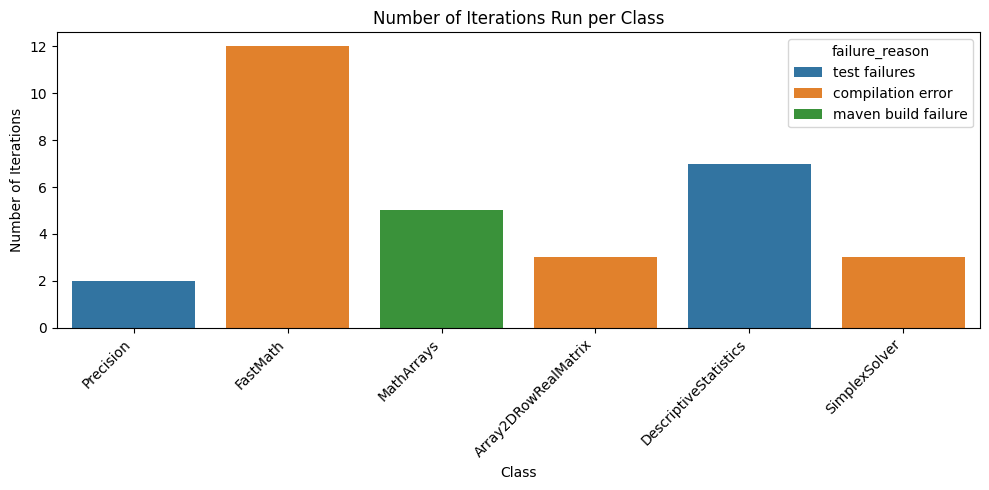

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=class_summary,
    x="class_name",
    y="num_iterations",
    hue="failure_reason",
    palette=palette,
    hue_order=failure_order
)

plt.xlabel("Class")
plt.ylabel("Number of Iterations")
plt.title("Number of Iterations Run per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


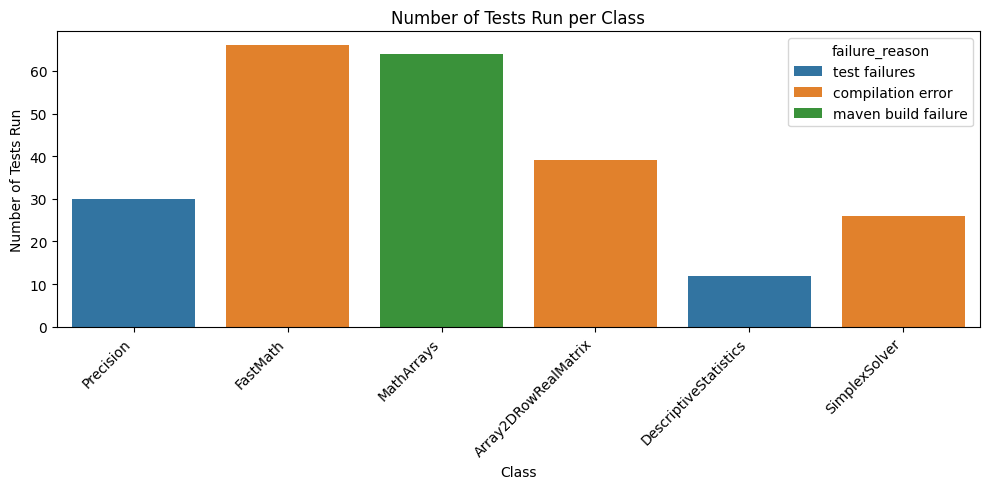

In [37]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=class_summary,
    x="class_name",
    y="num_tests_run",
    hue="failure_reason",
    palette=palette,
    hue_order=failure_order
)

plt.xlabel("Class")
plt.ylabel("Number of Tests Run")
plt.title("Number of Tests Run per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Refactoring Miner

In [38]:
TARGET_CLASSES = [
    "Precision",
    "FastMath",
    "MathArrays",
    "Array2DRowRealMatrix",
    "DescriptiveStatistics",
    "SimplexSolver"
]

In [39]:
refactoring_types = ['Add Variable Modifier',
 'Change Variable Type',
 'Extract Attribute',
 'Extract Method',
 'Extract Variable',
 'Inline Variable',
 'Invert Condition',
 'Parameterize Attribute',
 'Parameterize Variable',
 'Rename Parameter',
 'Rename Variable',
 'Replace Variable With Attribute']

palette = dict(zip(
    refactoring_types,
    sns.color_palette("tab20", n_colors=len(refactoring_types))
))


## types of refactoring across instances

In [40]:
from matplotlib.ticker import MaxNLocator

def plot_refactorings_per_class(
    df,
    iter_col="iter_no",
    refactoring_type_col="refactoring_type",
    class_name=None,
    figsize=(12, 6)
):
    """
    Plots refactoring instance counts per iteration,
    with refactoring type shown as hue (one plot per class).
    """

    counts = (
        df
        .groupby([iter_col, refactoring_type_col])
        .size()
        .reset_index(name="count")
    )

    counts[iter_col] = counts[iter_col].astype(int)
    max_iter = counts[iter_col].max()
    full_iters = list(range(1, max_iter + 1))

    counts = (
        counts
        .set_index(iter_col)
        .groupby(refactoring_type_col, group_keys=False)
        .apply(lambda g: g.reindex(full_iters, fill_value=0))
        .reset_index()
        .rename(columns={"index": iter_col})
    )

    counts[iter_col] = pd.Categorical(
        counts[iter_col],
        categories=full_iters,
        ordered=True
    )

    present_types = [
        t for t in refactoring_types
        if t in counts[refactoring_type_col].unique()
    ]

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=counts,
        x=iter_col,
        y="count",
        hue=refactoring_type_col,
        hue_order=present_types,
        palette=palette
    )

    title = "Refactoring Instances per Iteration"
    if class_name:
        title += f" — {class_name}"

    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Number of Refactoring Instances")

    # ✅ Enforce integer y-axis
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    ax.legend(
        title="Refactoring Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()


Plotting refactorings for class: Precision


/var/folders/1n/_3thx1k14g91g4_4q55m_mn00000gq/T/ipykernel_3967/1406926236.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.reindex(full_iters, fill_value=0))


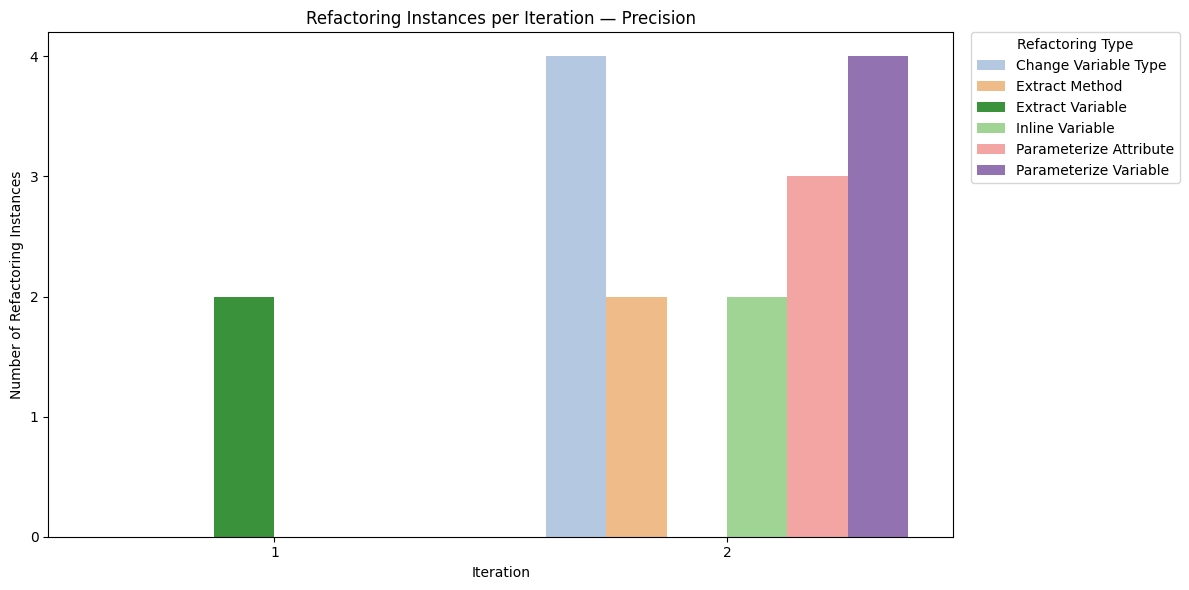

Plotting refactorings for class: FastMath


/var/folders/1n/_3thx1k14g91g4_4q55m_mn00000gq/T/ipykernel_3967/1406926236.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.reindex(full_iters, fill_value=0))


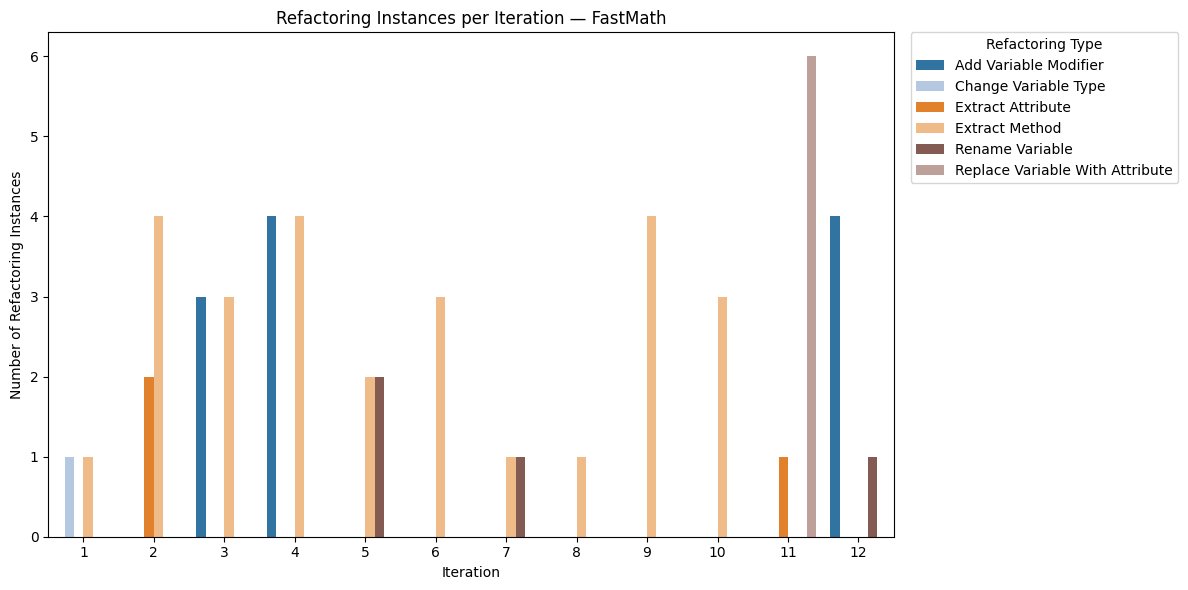

Plotting refactorings for class: MathArrays


/var/folders/1n/_3thx1k14g91g4_4q55m_mn00000gq/T/ipykernel_3967/1406926236.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.reindex(full_iters, fill_value=0))


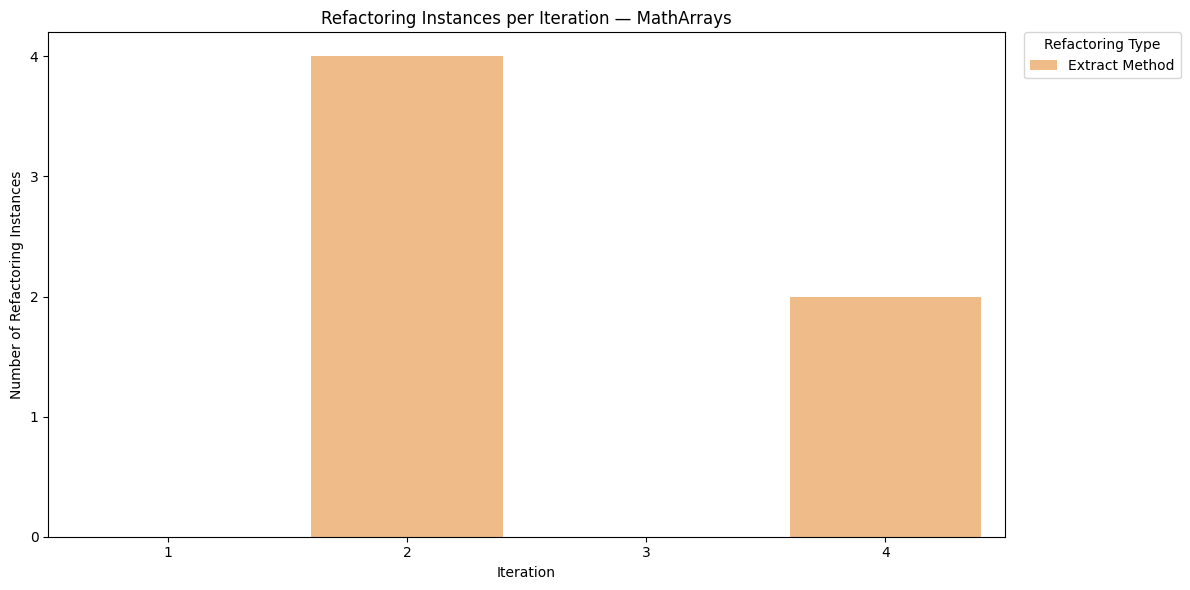

Plotting refactorings for class: Array2DRowRealMatrix


/var/folders/1n/_3thx1k14g91g4_4q55m_mn00000gq/T/ipykernel_3967/1406926236.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.reindex(full_iters, fill_value=0))


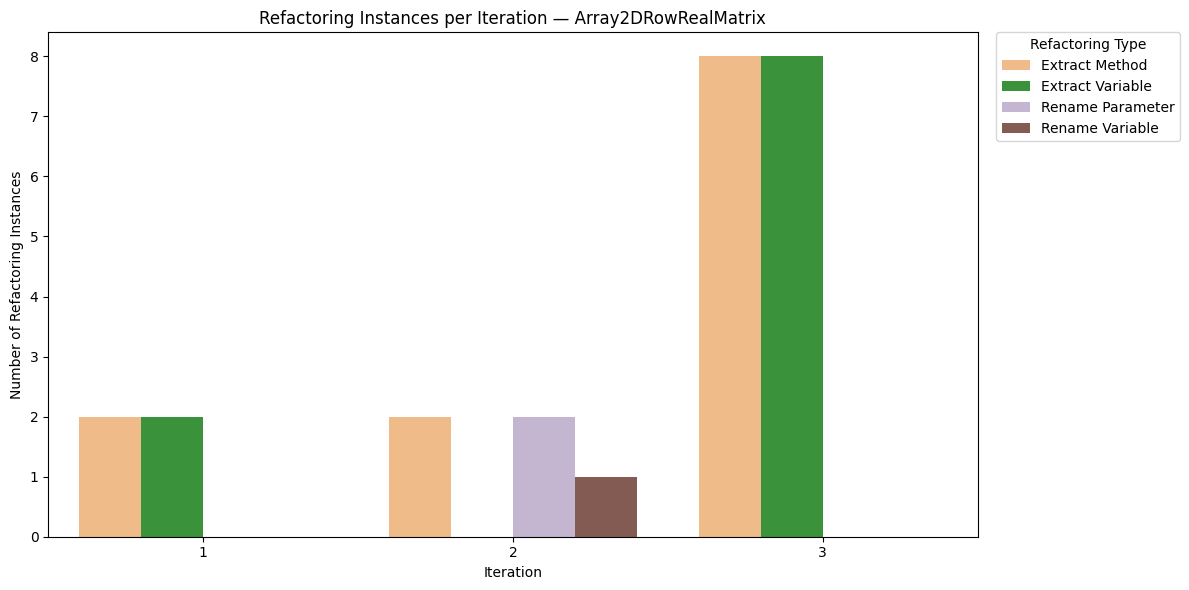

Plotting refactorings for class: DescriptiveStatistics


/var/folders/1n/_3thx1k14g91g4_4q55m_mn00000gq/T/ipykernel_3967/1406926236.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.reindex(full_iters, fill_value=0))


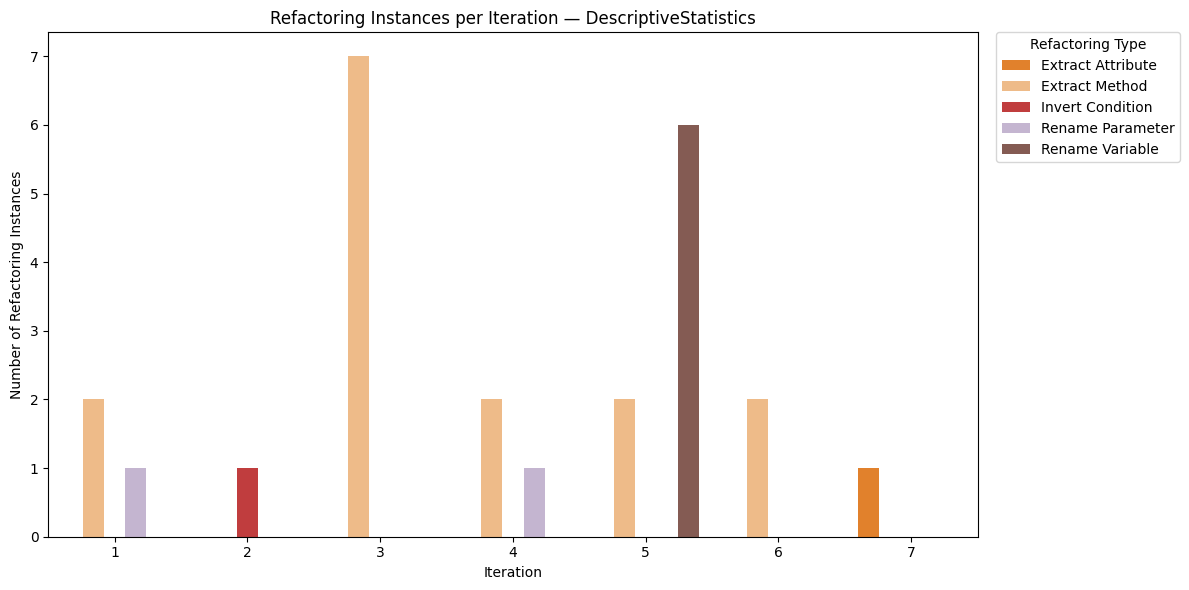

Plotting refactorings for class: SimplexSolver


/var/folders/1n/_3thx1k14g91g4_4q55m_mn00000gq/T/ipykernel_3967/1406926236.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.reindex(full_iters, fill_value=0))


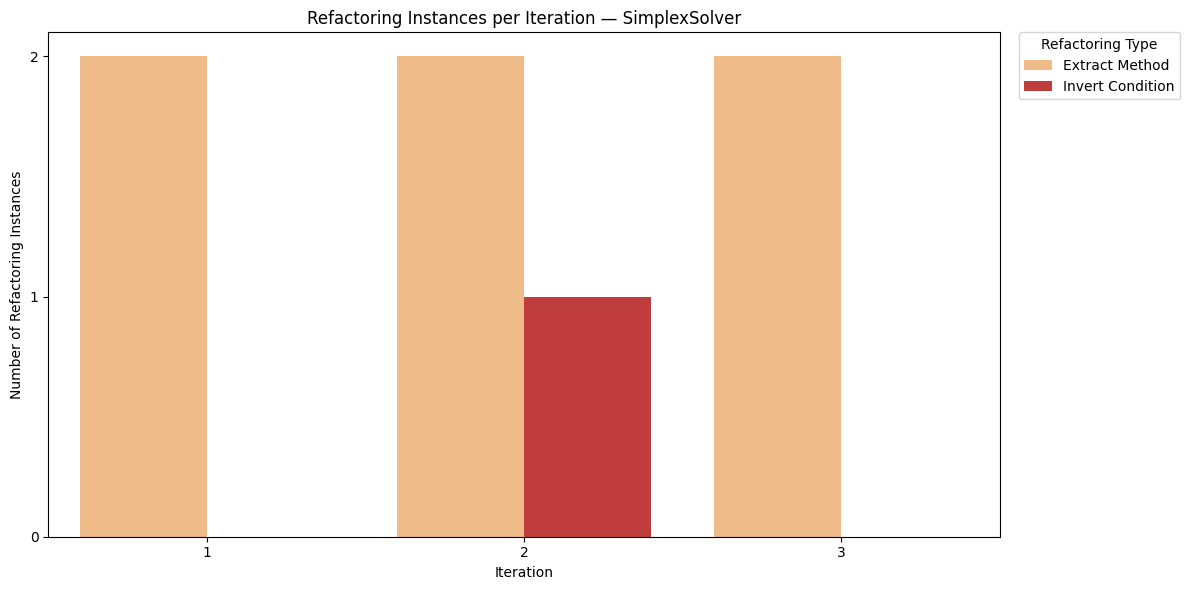

In [41]:
BASE_DIR = Path("RefactoringMiner")

for class_name in TARGET_CLASSES:
    csv_path = BASE_DIR / class_name / "summary_refactorings.csv"

    if not csv_path.exists():
        print(f"[WARN] Missing file for {class_name}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    print(f"Plotting refactorings for class: {class_name}")

    plot_refactorings_per_class(
        df,
        iter_col="iter_no",
        refactoring_type_col="refactoring_type",
        class_name=class_name
    )


## number of refactoring instances per iteration

In [42]:

def plot_stacked_refactorings_per_iteration(
    df,
    iter_col="iter_no",
    refactoring_type_col="refactoring_type",
    class_name=None,
    figsize=(12, 6)
):
    """
    Creates a stacked bar plot comparing the number of refactoring
    instances per iteration, stacked by refactoring type.
    Ensures iterations start at 1 and missing iterations are shown.
    """

    # Aggregate counts
    counts = (
        df
        .groupby([iter_col, refactoring_type_col])
        .size()
        .reset_index(name="count")
    )

    # Ensure iteration is integer
    counts[iter_col] = counts[iter_col].astype(int)
    max_iter = counts[iter_col].max()
    full_iters = np.arange(1, max_iter + 1)

    full_index = pd.MultiIndex.from_product(
        [full_iters, counts[refactoring_type_col].unique()],
        names=[iter_col, refactoring_type_col]
    )

    counts = (
        counts
        .set_index([iter_col, refactoring_type_col])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    # Pivot for stacking
    pivot = (
        counts
        .pivot(index=iter_col, columns=refactoring_type_col, values="count")
        .fillna(0)
        .astype(int)
        .sort_index()
    )

    # Keep global order but only present types
    ordered_types = [t for t in refactoring_types if t in pivot.columns]
    pivot = pivot[ordered_types]

    fig, ax = plt.subplots(figsize=figsize)

    bottom = np.zeros(len(pivot))
    for ref_type in pivot.columns:
        ax.bar(
            pivot.index,
            pivot[ref_type],
            bottom=bottom,
            color=palette[ref_type],
            label=ref_type
        )
        bottom += pivot[ref_type].values

    title = "Refactoring Instances per Iteration"
    if class_name is not None:
        title += f" — {class_name}"

    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Number of Refactoring Instances")

    ax.set_xlim(0.5, max_iter + 0.5)
    ax.set_xticks(full_iters)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.legend(
        title="Refactoring Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    # 🔑 Add headroom above tallest stacked bar
    max_height = pivot.sum(axis=1).max()
    ax.set_ylim(0, max_height * 1.1)  # 10% padding

    fig.tight_layout()
    plt.show()


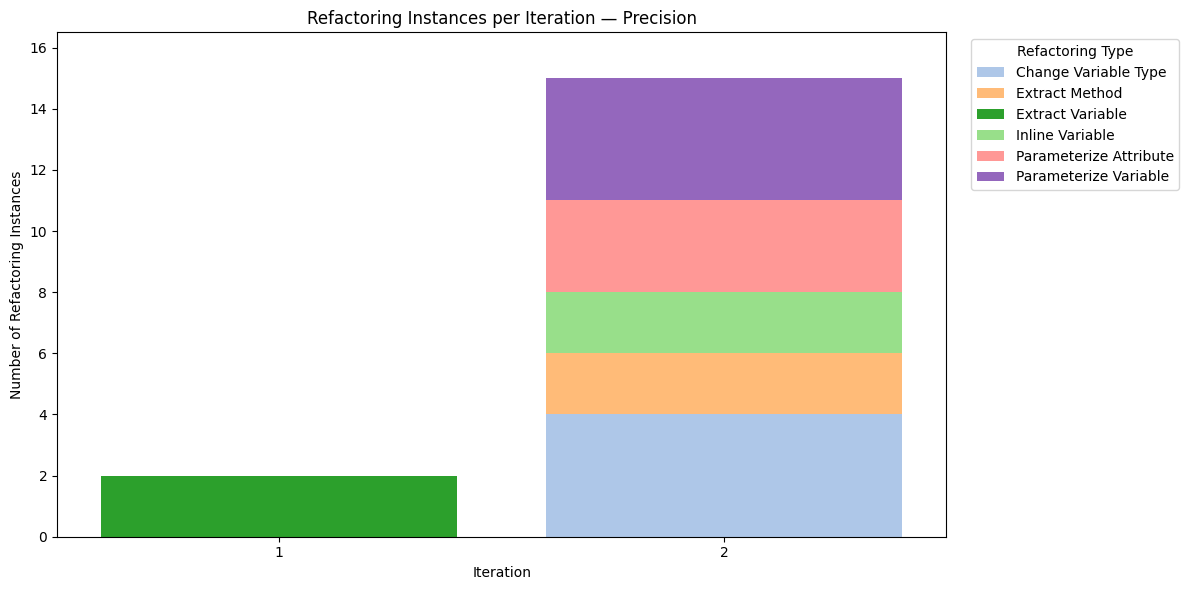

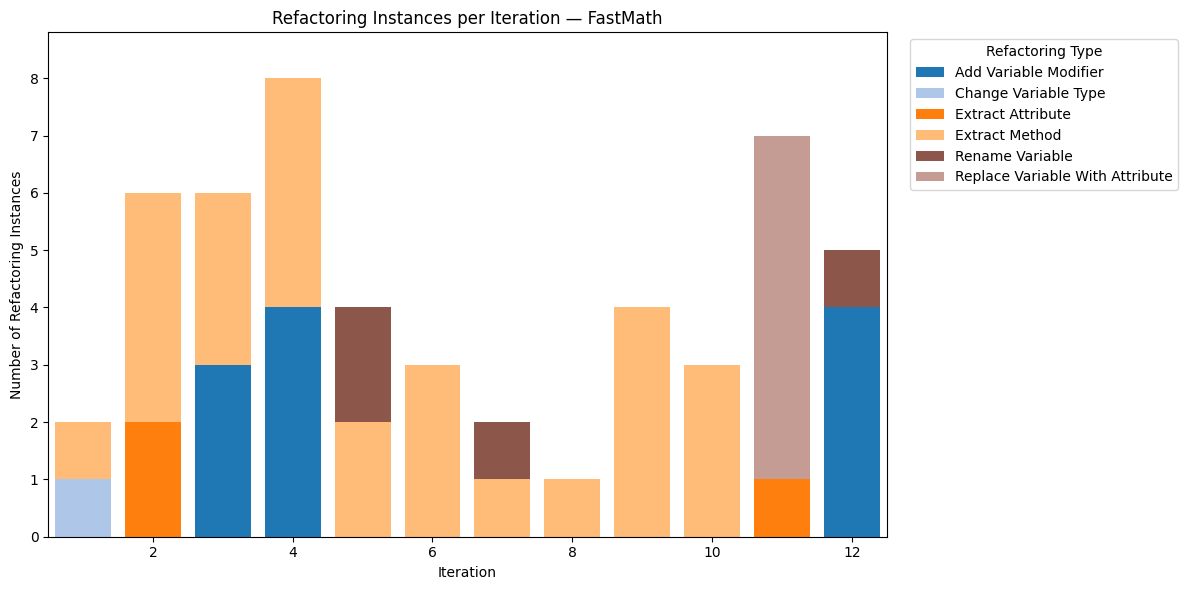

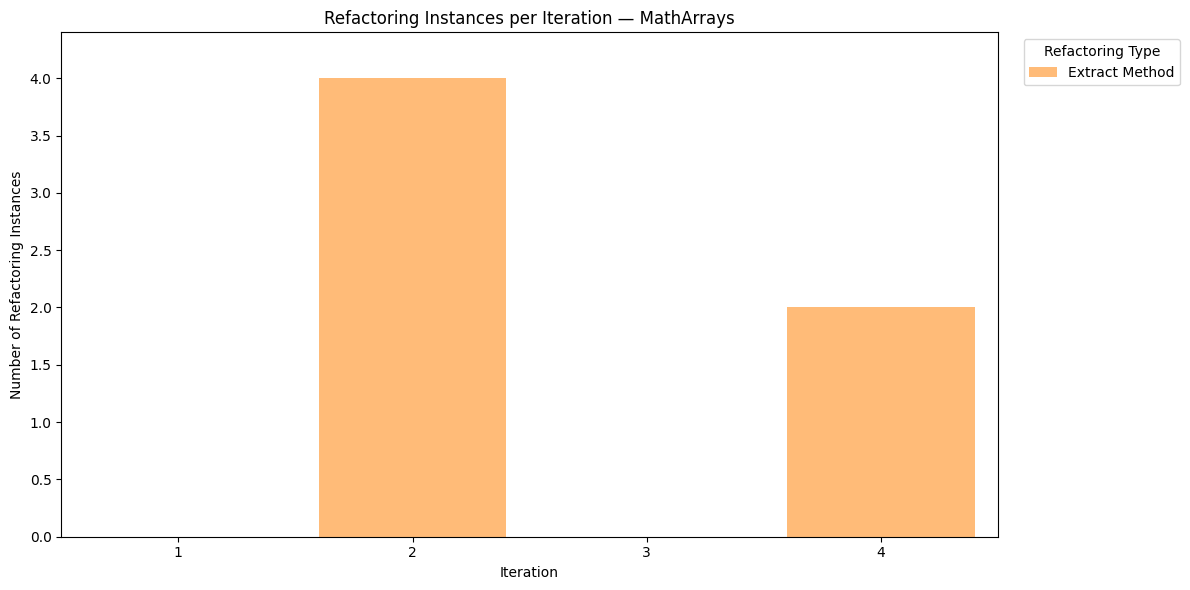

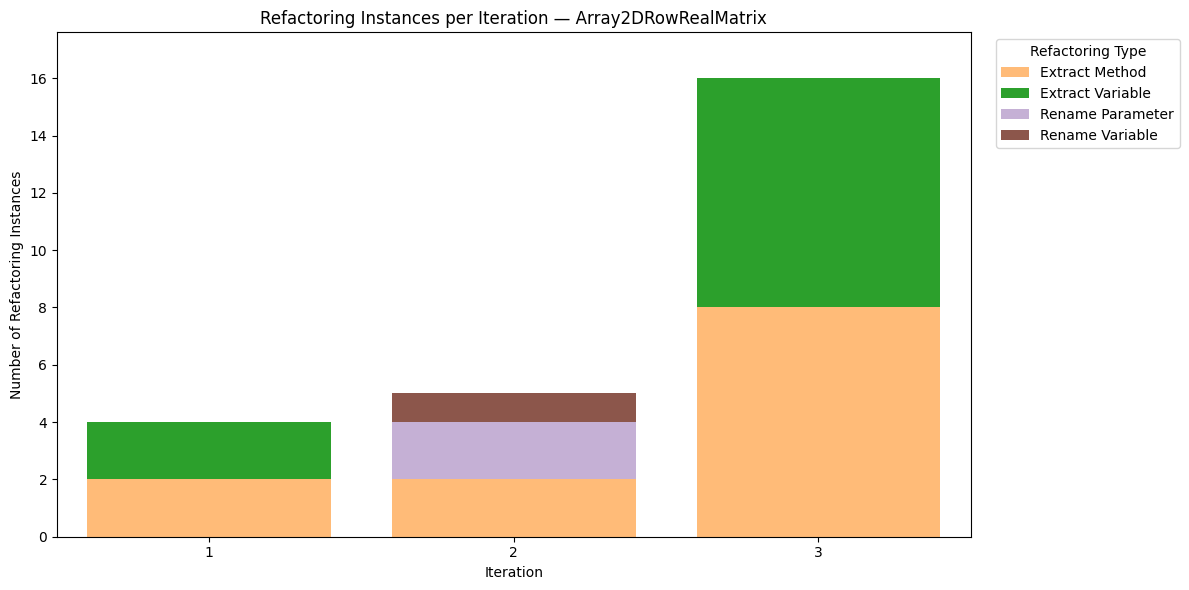

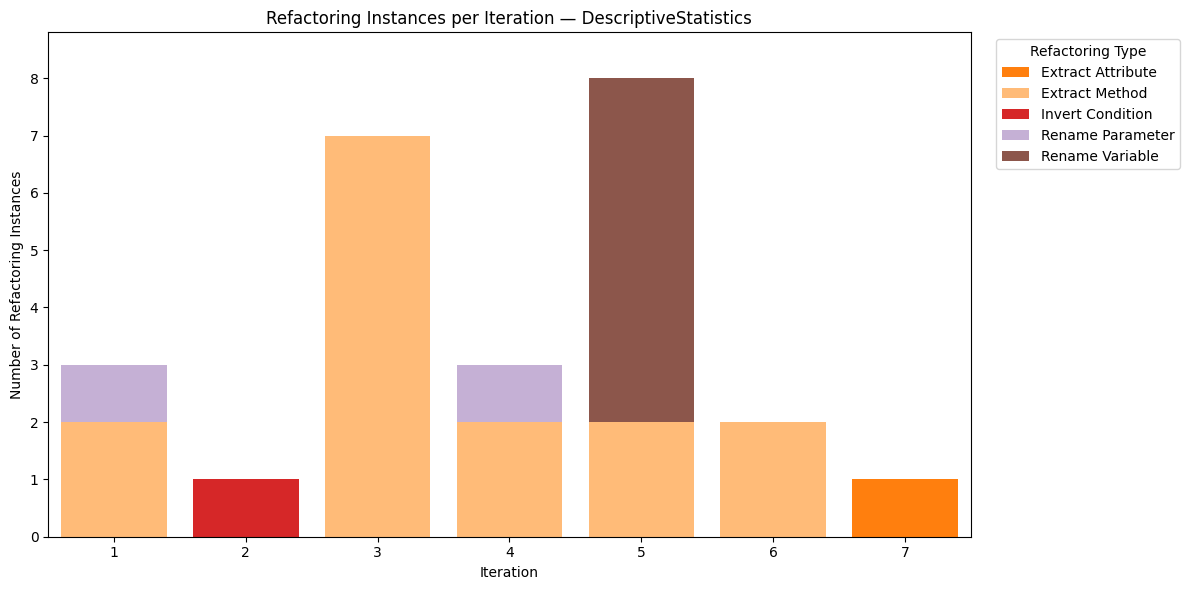

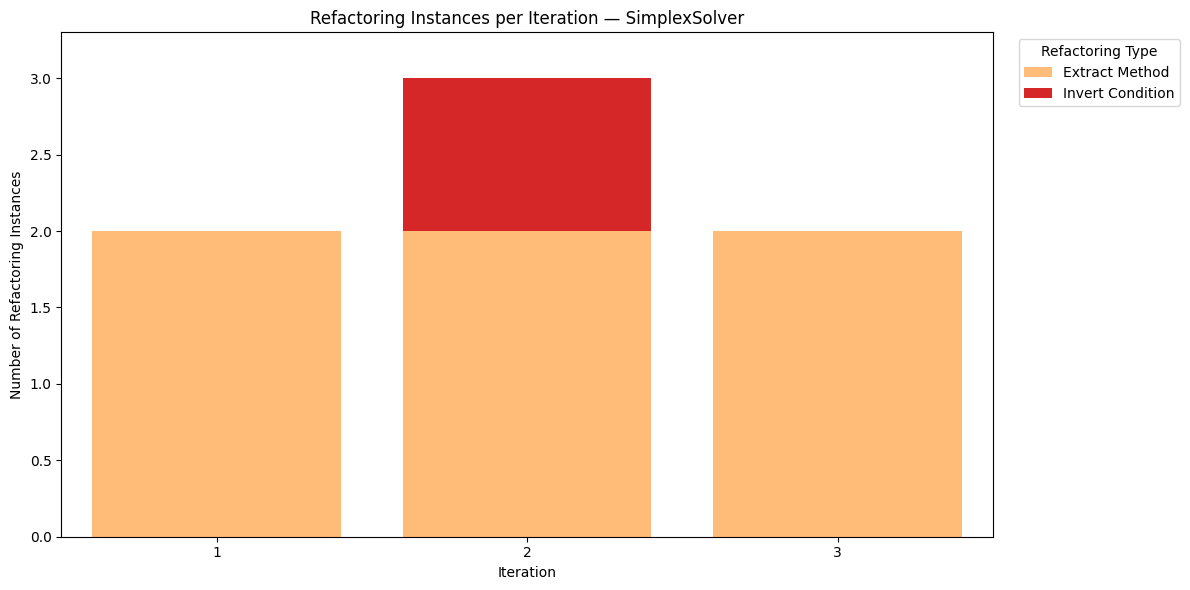

In [43]:
for class_name in TARGET_CLASSES:
    csv_path = BASE_DIR / class_name / "summary_refactorings.csv"

    if not csv_path.exists():
        print(f"[WARN] Missing file for {class_name}")
        continue

    df = pd.read_csv(csv_path)

    plot_stacked_refactorings_per_iteration(
        df,
        class_name=class_name
    )


This one is interesting because `MathArrays` has no refactoring instances in some iterations

# Designite

## code smells


In [44]:

code_smell_types = [
    'Cyclic-Dependent Modularization',
    'Deficient Encapsulation',
    'Insufficient Modularization',
    'Multifaceted Abstraction',
    'Unutilized Abstraction'
]

code_smell_palette = {
    smell: color
    for smell, color in zip(code_smell_types, sns.color_palette("tab20", len(code_smell_types)))
}


In [45]:
def plot_code_smells_per_class(
    df,
    iter_col="iter_no",
    code_smell_col="code_smell",
    class_name=None,
    figsize=(12, 6),
    palette=code_smell_palette
):
    """
    Creates a stacked bar plot comparing the number of code smells
    per iteration (including baseline iter_no = 0),
    stacked by code smell type.
    """

    # Aggregate counts
    counts = (
        df
        .groupby([iter_col, code_smell_col])
        .size()
        .reset_index(name="count")
    )

    counts[iter_col] = counts[iter_col].astype(int)

    # 🔑 Full iteration range starting at 0
    min_iter = 0
    max_iter = counts[iter_col].max()
    full_iters = np.arange(min_iter, max_iter + 1)

    full_index = pd.MultiIndex.from_product(
        [full_iters, counts[code_smell_col].unique()],
        names=[iter_col, code_smell_col]
    )

    counts = (
        counts
        .set_index([iter_col, code_smell_col])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    # Pivot for stacking
    pivot = (
        counts
        .pivot(index=iter_col, columns=code_smell_col, values="count")
        .fillna(0)
        .astype(int)
        .sort_index()
    )

    # Only plot smells present, but keep global color mapping
    ordered_smells = [s for s in palette if s in pivot.columns]
    pivot = pivot[ordered_smells]

    fig, ax = plt.subplots(figsize=figsize)

    bottom = np.zeros(len(pivot))
    for smell in pivot.columns:
        ax.bar(
            pivot.index,
            pivot[smell],
            bottom=bottom,
            color=palette[smell],
            label=smell
        )
        bottom += pivot[smell].values

    title = "Code Smells per Iteration (Stacked)"
    if class_name is not None:
        title += f" — {class_name}"

    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Number of Code Smells")

    # ✅ Correct 0-based axis behavior
    ax.set_xlim(-0.5, max_iter + 0.5)
    ax.set_xticks(full_iters)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # ✅ Headroom above tallest stack
    max_height = pivot.sum(axis=1).max()
    ax.set_ylim(0, max_height * 1.1)

    ax.legend(
        title="Code Smell Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    fig.tight_layout()
    plt.show()


Plotting code smells for class: Precision


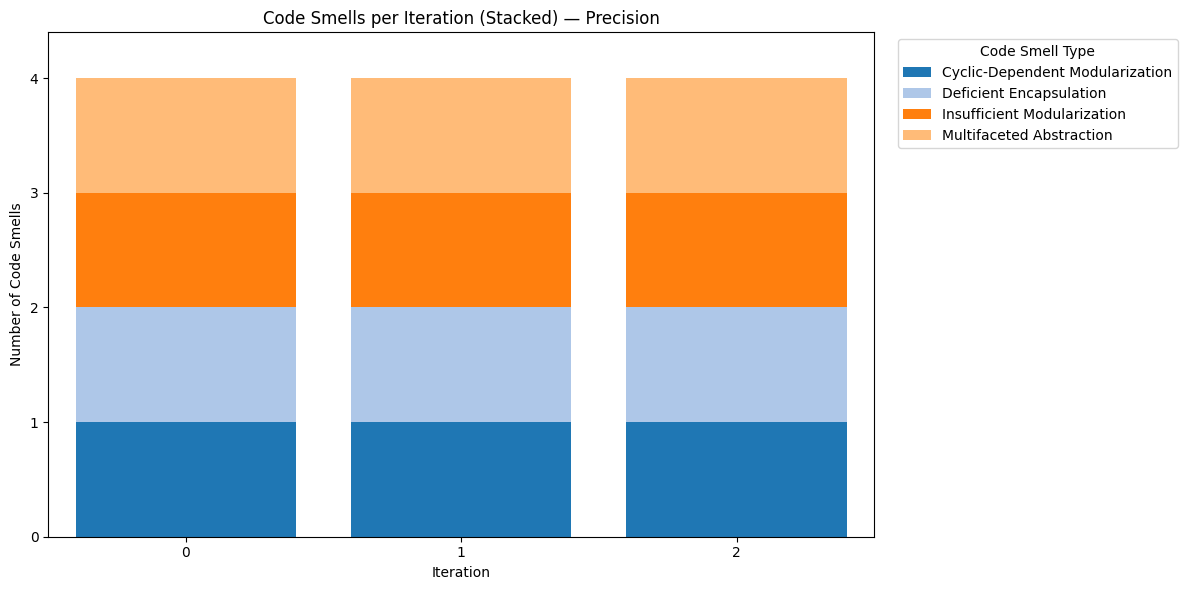

Plotting code smells for class: FastMath


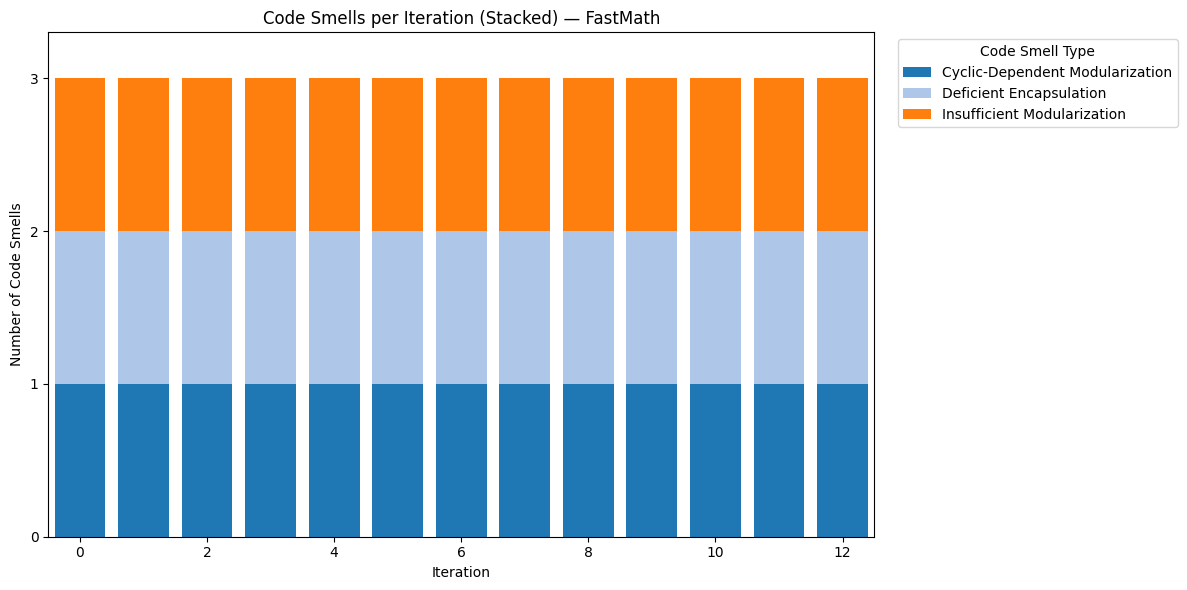

Plotting code smells for class: MathArrays


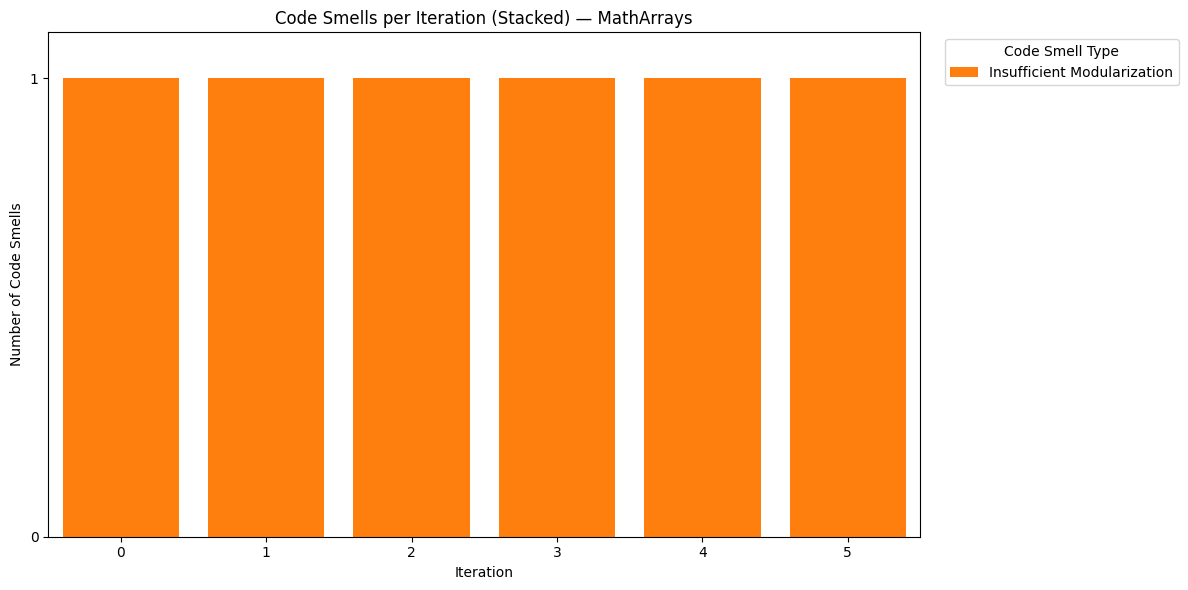

Plotting code smells for class: Array2DRowRealMatrix


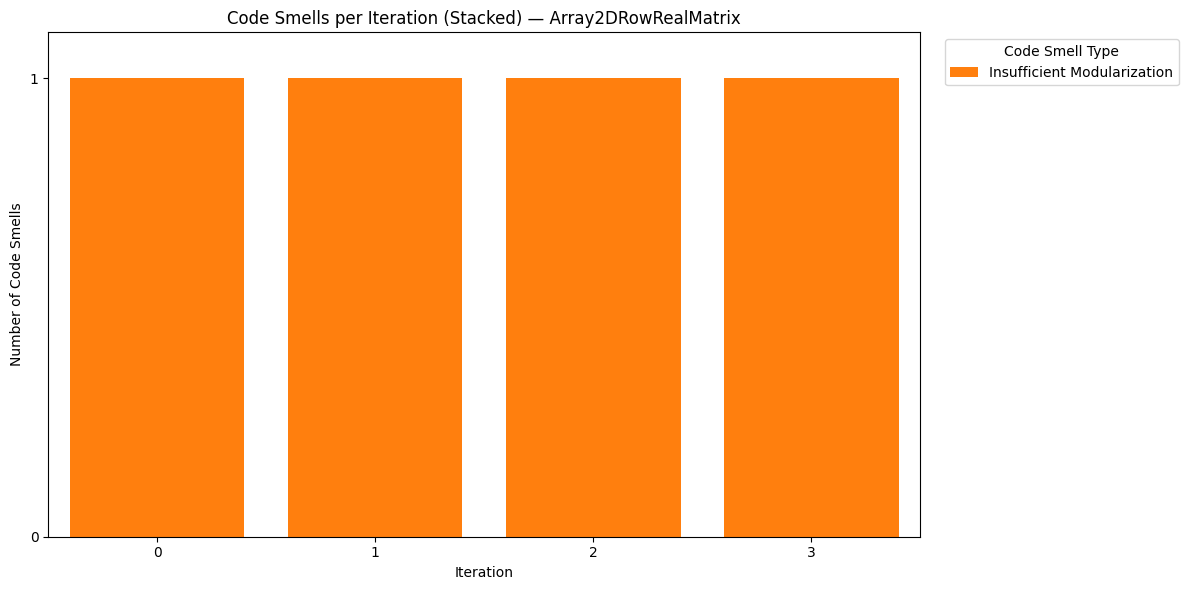

Plotting code smells for class: DescriptiveStatistics


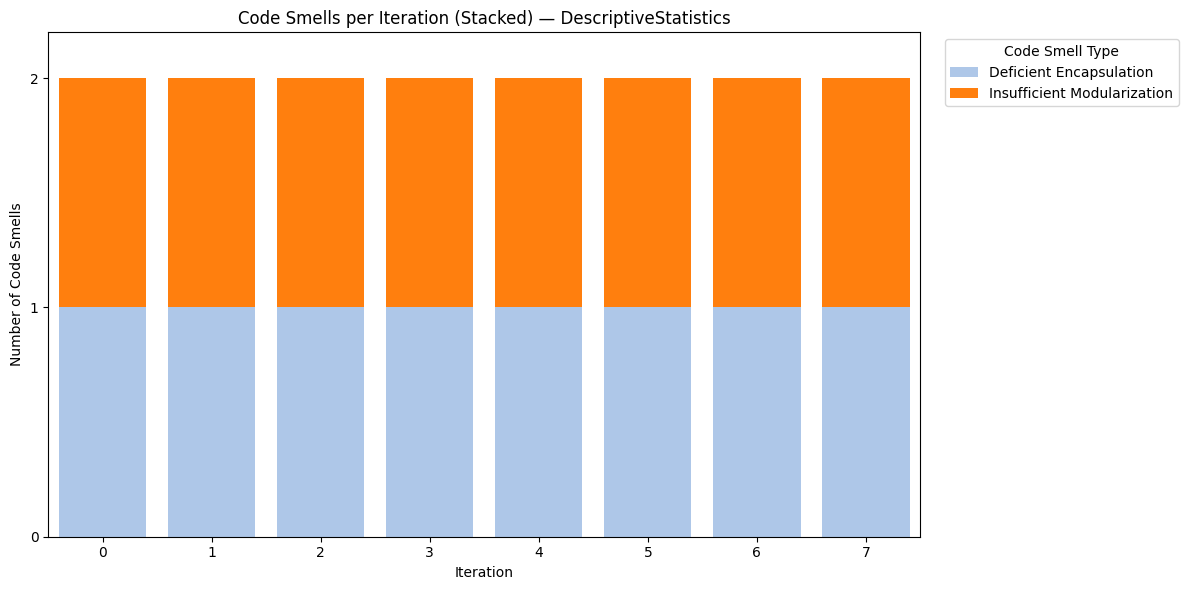

Plotting code smells for class: SimplexSolver


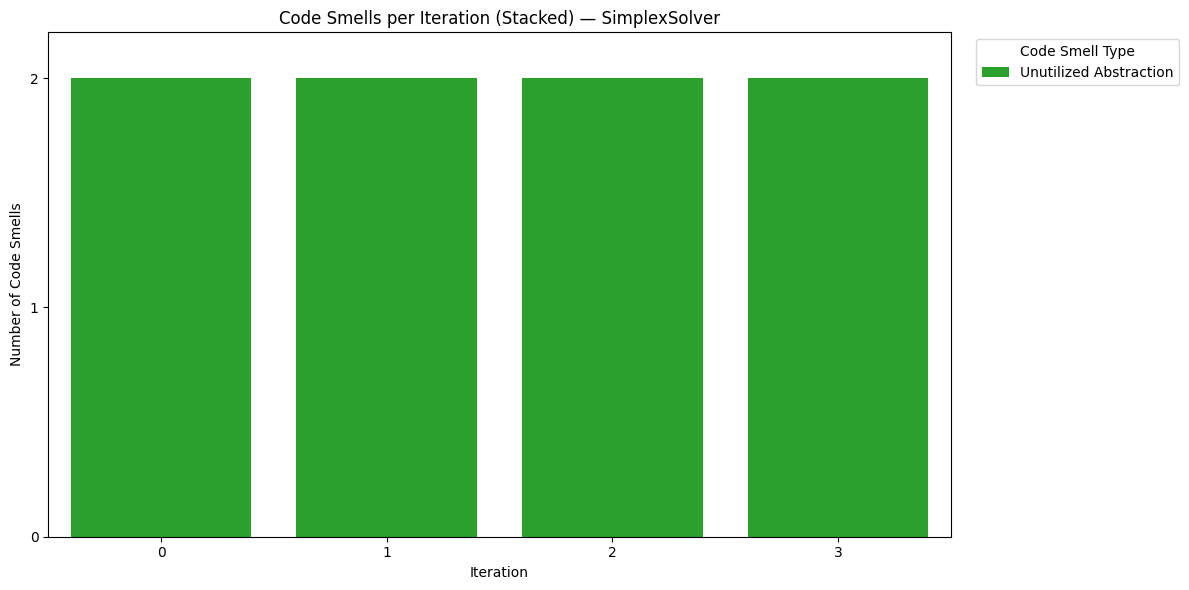

In [46]:

DESIGNITE_BASE_DIR = Path("designite")
for class_name in TARGET_CLASSES:
    csv_path = DESIGNITE_BASE_DIR / class_name / "designite_smells_long.csv"

    if not csv_path.exists():
        print(f"[WARN] Missing file for {class_name}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    print(f"Plotting code smells for class: {class_name}")

    plot_code_smells_per_class(
        df,
        iter_col="iter_no",
        code_smell_col="code_smell",
        class_name=class_name,
        palette=code_smell_palette
    )


## designite metrics

### metrics over iterations

In [47]:

def plot_type_metrics_over_iterations(
    df,
    class_name: str | None = None,
    metrics: list[str] | None = None,
    ncols: int = 3,
    figsize: tuple = (14, 10),
):
    """
    Plot Designite type metrics across refactoring iterations using
    small-multiples line plots.
    """

    if metrics is None:
        metrics = [c for c in df.columns if c != "iter_no"]

    n_metrics = len(metrics)
    nrows = ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=False,
    )

    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        ax.plot(
            df["iter_no"],
            df[metric],
            marker="o",
        )
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)

        # ✅ Enforce integer x-axis
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for ax in axes[n_metrics:]:
        ax.axis("off")

    title = "Type Metrics Across Refactoring Iterations"
    if class_name:
        title += f" — {class_name}"

    fig.suptitle(title, fontsize=16)
    fig.supxlabel("Iteration")

    plt.tight_layout()
    plt.show()

Plotting code smells for class: Precision


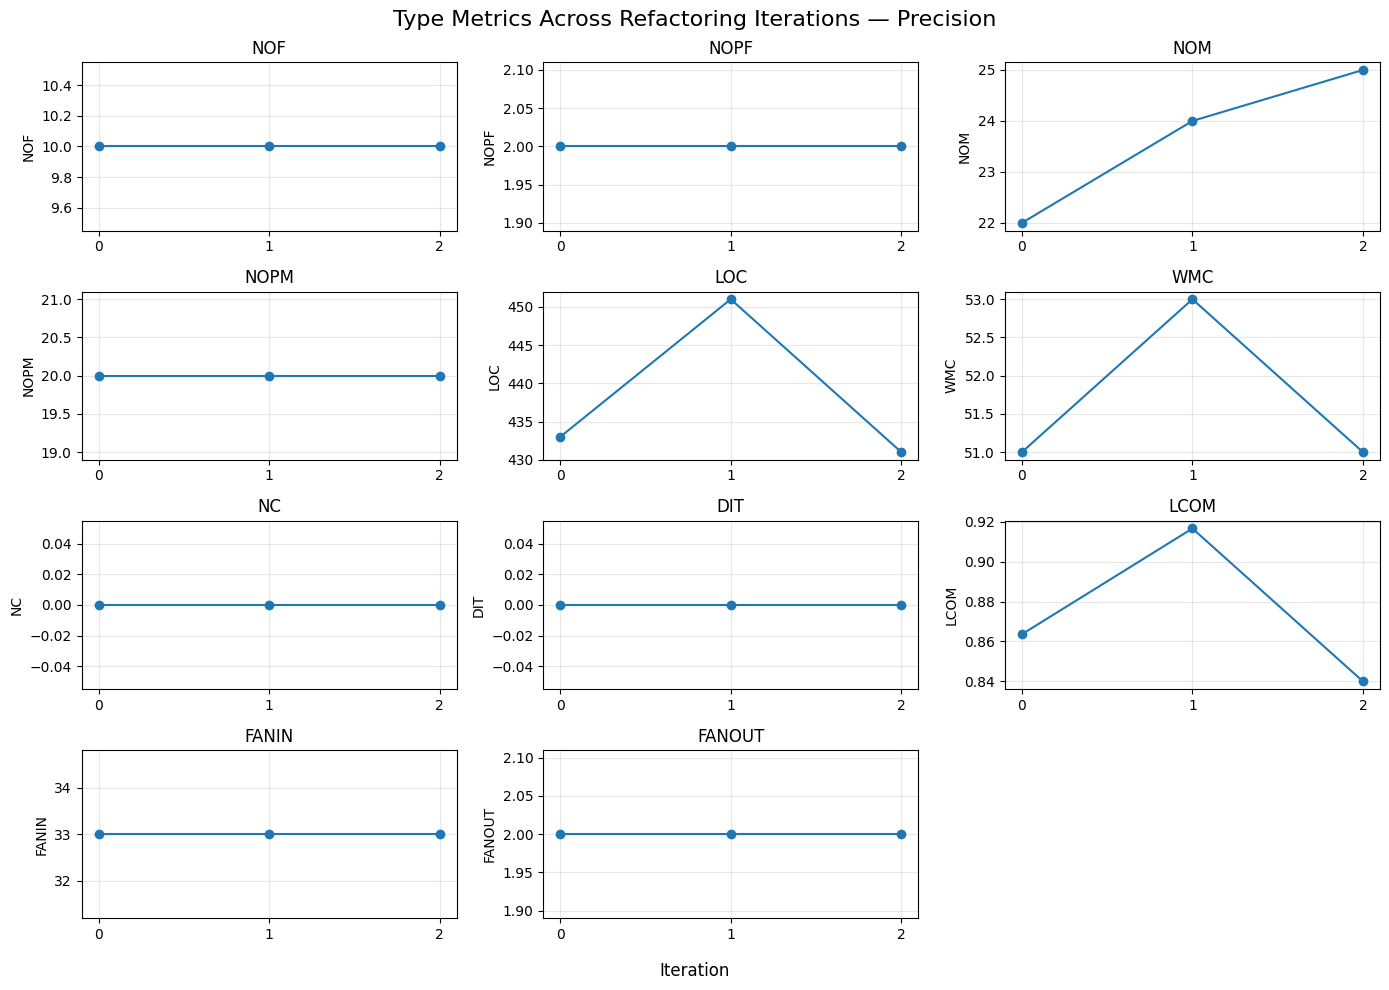

Plotting code smells for class: FastMath


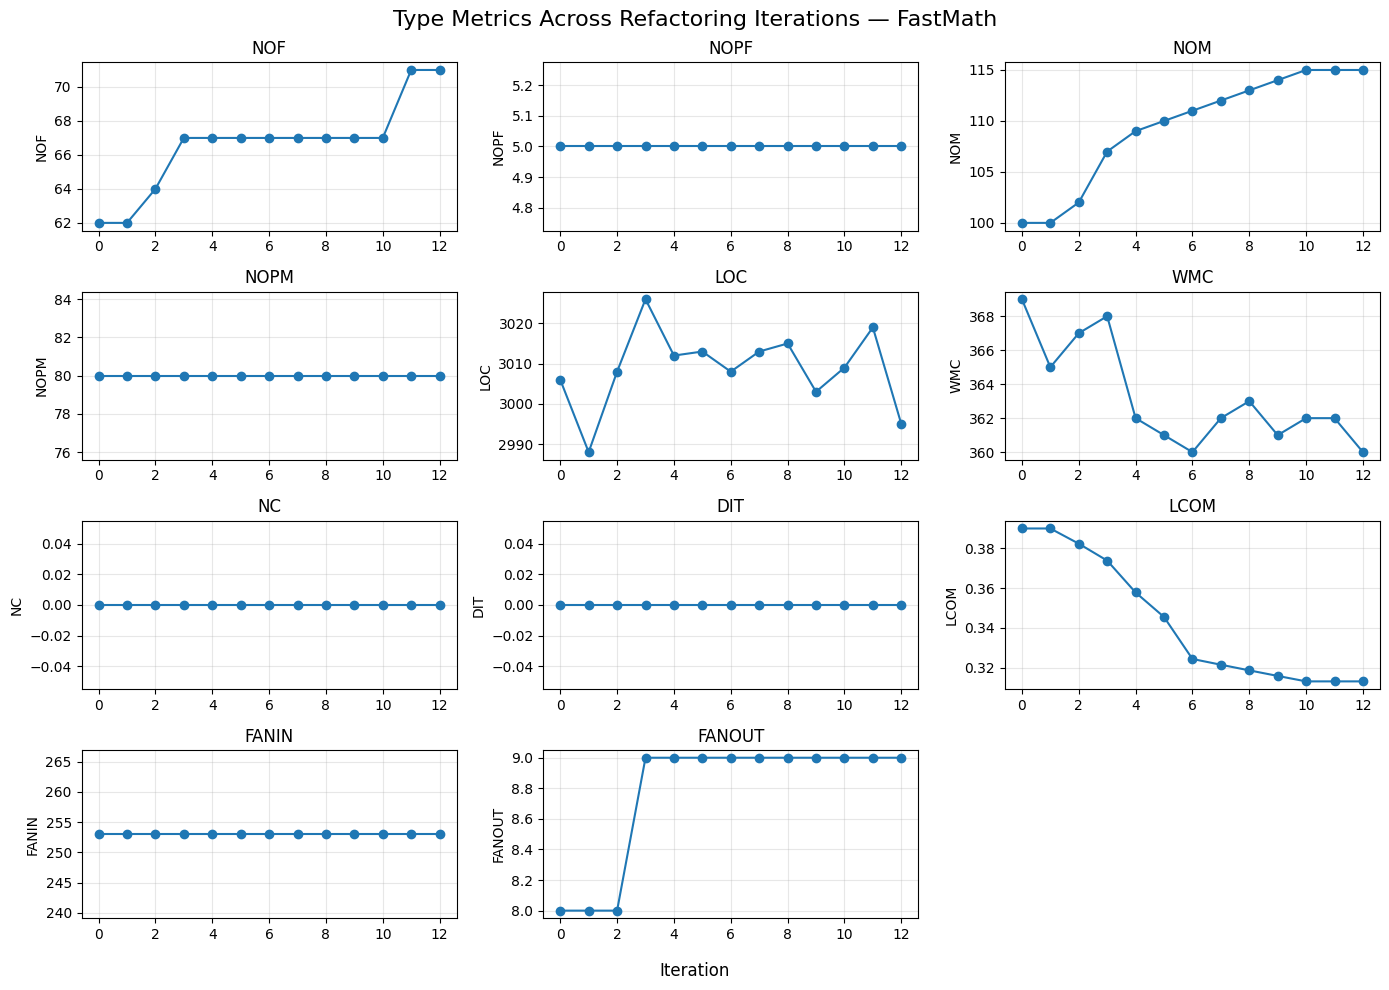

Plotting code smells for class: MathArrays


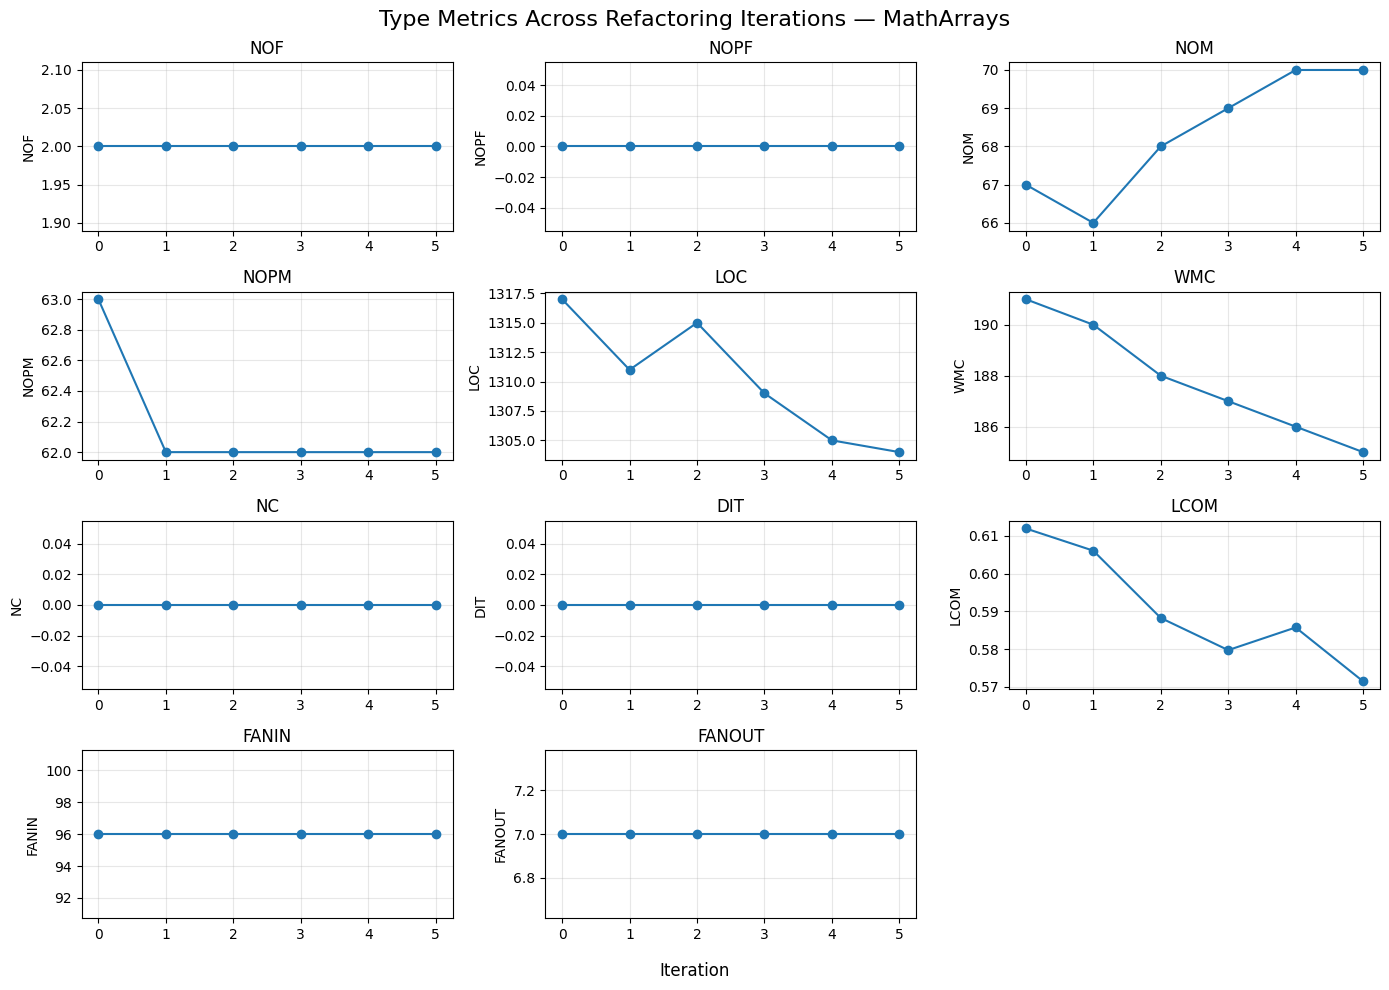

Plotting code smells for class: Array2DRowRealMatrix


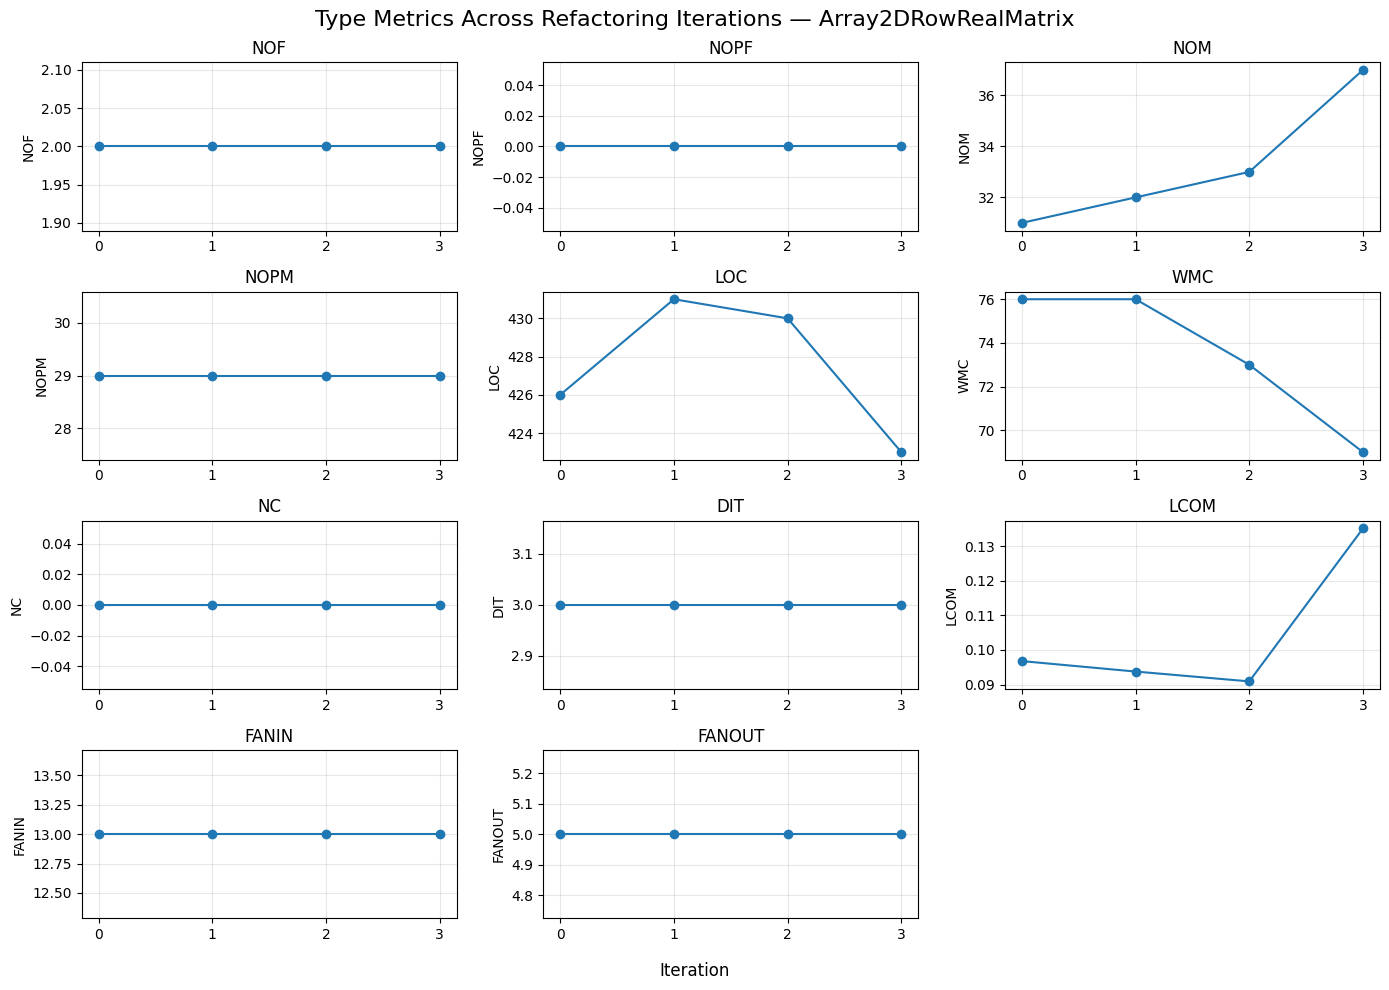

Plotting code smells for class: DescriptiveStatistics


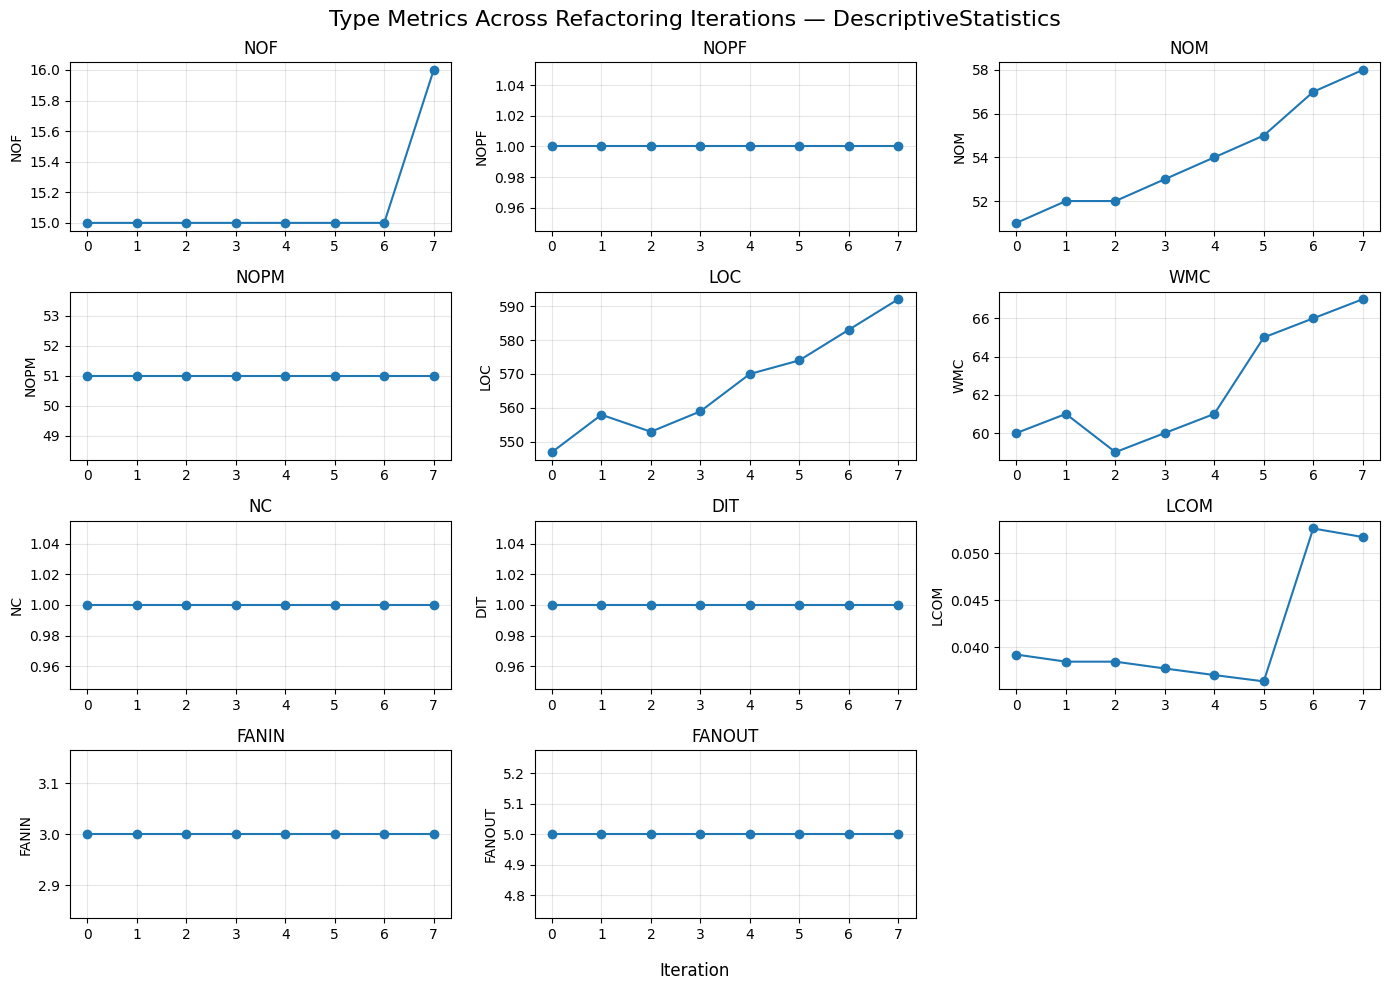

Plotting code smells for class: SimplexSolver


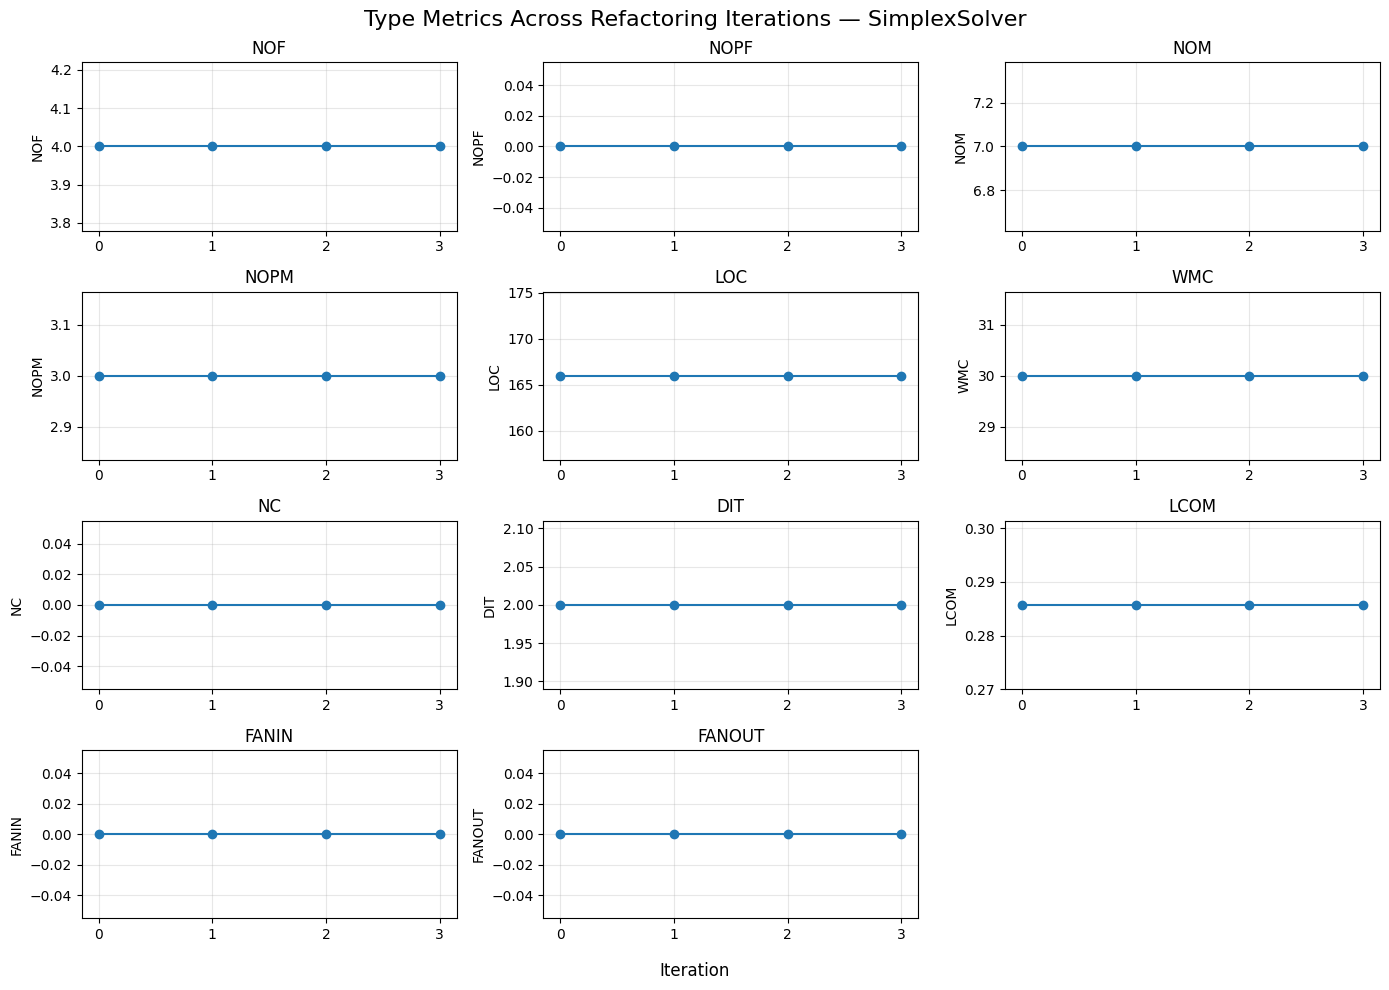

In [49]:
DESIGNITE_BASE_DIR = Path("designite")
for class_name in TARGET_CLASSES:
    csv_path = DESIGNITE_BASE_DIR / class_name / "designite_type_metrics.csv"

    if not csv_path.exists():
        print(f"[WARN] Missing file for {class_name}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df = df.drop(columns=['Project Name', 'Package Name', 'Type Name'])
    print(f"Plotting code smells for class: {class_name}")

    plot_type_metrics_over_iterations(
        df,
        class_name=class_name
    )


### metric deltas

In [50]:
metrics = ["NOF",
           "NOPF",
           "NOM",
           "NOPM",
           "LOC",
           "WMC",
           "NC",
           "DIT",
           "LCOM",
           "FANIN",
           "FANOUT"]



In [51]:
metrics_deltas_summary = {}

for class_name in TARGET_CLASSES:
    csv_path = DESIGNITE_BASE_DIR / class_name / "designite_type_metrics.csv"

    if not csv_path.exists():
        print(f"[WARN] Missing file for {class_name}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df = df.drop(columns=['Project Name', 'Package Name', 'Type Name'])

    class_dict = {}
    num_iters = df['iter_no'].max()
    class_dict['num_iterations'] = num_iters
    
    orig_metrics = df[df['iter_no'] == 0]
    final_metrics = df[df['iter_no'] == num_iters]

    for metric in metrics:
        class_dict[f'before_{metric}'] = orig_metrics[metric].item()
        class_dict[f'after_{metric}'] = final_metrics[metric].item()
        class_dict[f'delta_{metric}'] = orig_metrics[metric].item() - final_metrics[metric].item()

    metrics_deltas_summary[class_name] = class_dict
    

In [52]:
metrics_deltas_summary_df = pd.DataFrame.from_dict(metrics_deltas_summary, orient='index')
# metrics_deltas_summary_df.to_csv("designite/type_metrics_summary.csv")
metrics_deltas_summary_df

,num_iterations,before_NOF,after_NOF,delta_NOF,before_NOPF,after_NOPF,delta_NOPF,before_NOM,after_NOM,delta_NOM,...,delta_DIT,before_LCOM,after_LCOM,delta_LCOM,before_FANIN,after_FANIN,delta_FANIN,before_FANOUT,after_FANOUT,delta_FANOUT
Precision,2,10,10,0,2,2,0,22,25,-3,...,0,0.863636,0.840000,0.023636,33,33,0,2,2,0
FastMath,12,62,71,-9,5,5,0,100,115,-15,...,0,0.390000,0.313043,0.076957,253,253,0,8,9,-1
MathArrays,5,2,2,0,0,0,0,67,70,-3,...,0,0.611940,0.571429,0.040512,96,96,0,7,7,0
Array2DRowRealMatrix,3,2,2,0,0,0,0,31,37,-6,...,0,0.096774,0.135135,-0.038361,13,13,0,5,5,0
DescriptiveStatistics,7,15,16,-1,1,1,0,51,58,-7,...,0,0.039216,0.051724,-0.012508,3,3,0,5,5,0
SimplexSolver,3,4,4,0,0,0,0,7,7,0,...,0,0.285714,0.285714,0.000000,0,0,0,0,0,0


In [61]:
for m in metrics:
    metrics_deltas_summary_df[f"rel_delta_{m}"] = metrics_deltas_summary_df[f"delta_{m}"] / metrics_deltas_summary_df[f"before_{m}"]

metrics_deltas_summary_df

,num_iterations,before_NOF,after_NOF,delta_NOF,before_NOPF,after_NOPF,delta_NOPF,before_NOM,after_NOM,delta_NOM,...,rel_delta_WMC,rel_delta_LCOM,rel_delta_NOM,rel_delta_FANIN,rel_delta_FANOUT,rel_delta_NOF,rel_delta_NOPF,rel_delta_NOPM,rel_delta_NC,rel_delta_DIT
Precision,2,10,10,0,2,2,0,22,25,-3,...,0.000000,0.027368,-0.136364,0.0,0.000,0.000000,0.0,0.000000,NaN,NaN
FastMath,12,62,71,-9,5,5,0,100,115,-15,...,0.024390,0.197324,-0.150000,0.0,-0.125,-0.145161,0.0,0.000000,NaN,NaN
MathArrays,5,2,2,0,0,0,0,67,70,-3,...,0.031414,0.066202,-0.044776,0.0,0.000,0.000000,NaN,0.015873,NaN,NaN
Array2DRowRealMatrix,3,2,2,0,0,0,0,31,37,-6,...,0.092105,-0.396396,-0.193548,0.0,0.000,0.000000,NaN,0.000000,NaN,0.0
DescriptiveStatistics,7,15,16,-1,1,1,0,51,58,-7,...,-0.116667,-0.318966,-0.137255,0.0,0.000,-0.066667,0.0,0.000000,0.0,0.0
SimplexSolver,3,4,4,0,0,0,0,7,7,0,...,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,NaN,0.0


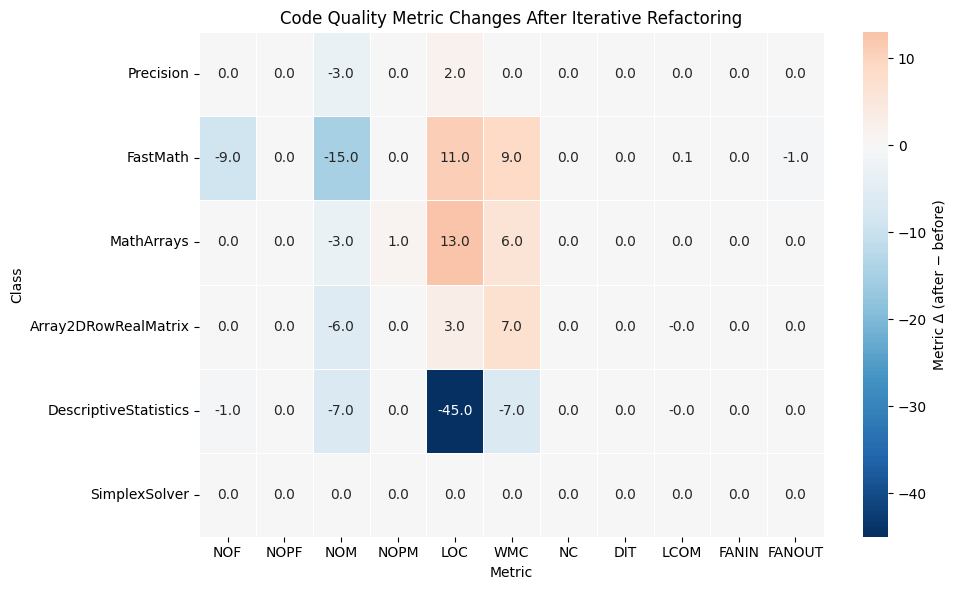

In [64]:
def plot_delta_heatmap(
    df,
    delta_prefix="delta_",
    figsize=(10, 6),
    cmap="RdBu_r",
    title="Code Quality Metric Changes After Iterative Refactoring",
    annotate=True,
):
    """
    Plot a heatmap showing positive vs negative metric deltas per class.

    Parameters
    ----------
    df : pd.DataFrame
        Index = class names
        Columns include delta_* metrics
    delta_prefix : str
        Prefix used to identify delta columns
    figsize : tuple
        Figure size
    cmap : str
        Diverging colormap (centered at 0)
    annotate : bool
        Whether to annotate cells with values
    """

    # Select only delta columns
    delta_cols = [c for c in df.columns if c.startswith(delta_prefix)]
    delta_df = df[delta_cols].copy()
    delta_df = delta_df.fillna(0)


    # Clean column names for display
    delta_df.columns = [c.replace(delta_prefix, "") for c in delta_df.columns]

    plt.figure(figsize=figsize)
    sns.heatmap(
        delta_df,
        center=0,
        cmap=cmap,
        annot=annotate,
        fmt=".1f",
        linewidths=0.5,
        cbar_kws={"label": "Metric Δ (after − before)"},
    )

    plt.title(title)
    plt.xlabel("Metric")
    plt.ylabel("Class")
    plt.tight_layout()
    plt.show()


plot_delta_heatmap(metrics_deltas_summary_df)



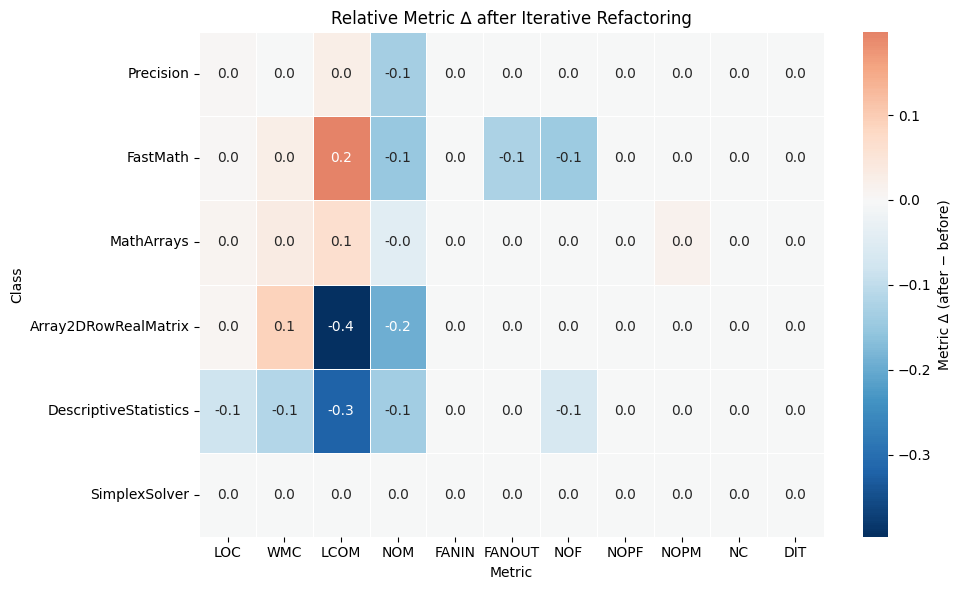

In [65]:
plot_delta_heatmap(metrics_deltas_summary_df, 
                   delta_prefix="rel_delta_",
                   title="Relative Metric ∆ after Iterative Refactoring")

In [72]:
def plot_relative_type_metrics_over_iterations(
    df,
    class_name: str | None = None,
    metrics: list[str] | None = None,
    ncols: int = 3,
    figsize: tuple = (14, 10),
    label_with_class: bool = False, 
):
    """
    Plot *relative deltas* of Designite type metrics across refactoring iterations
    using small-multiples line plots.

    Relative delta is computed w.r.t. the first iteration (baseline):
        (value - baseline) / baseline
    """

    if metrics is None:
        metrics = [c for c in df.columns if c != "iter_no"]

    # Sort just in case
    df = df.sort_values("iter_no").reset_index(drop=True)

    baseline = df.loc[0]

    # Compute relative deltas
    rel_df = df.copy()
    
    for m in metrics:
        if baseline[m] == 0:
            rel_df[m] = np.nan
        else:
            rel_df[m] = (df[m] - baseline[m]) / baseline[m]
    
    rel_df[metrics] = rel_df[metrics].fillna(0.0)
    n_metrics = len(metrics)
    nrows = ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=False,
    )

    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        ax.plot(
            rel_df["iter_no"],
            rel_df[metric],
            marker="o",
        )
        ax.axhline(0, color="black", linewidth=1, alpha=0.6)
        if label_with_class and class_name:
            ax.set_title(f"{metric} – {class_name}")
        else:
            ax.set_title(metric)        
        ax.set_ylabel("Relative Δ")
        ax.grid(True, alpha=0.3)

        # Enforce integer x-axis
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for ax in axes[n_metrics:]:
        ax.axis("off")

    title = "Relative Type Metric Δ Across Refactoring Iterations"
    if class_name:
        title += f" — {class_name}"

    fig.suptitle(title, fontsize=16)
    fig.supxlabel("Iteration")

    plt.tight_layout()
    plt.show()


Plotting code smells for class: Precision


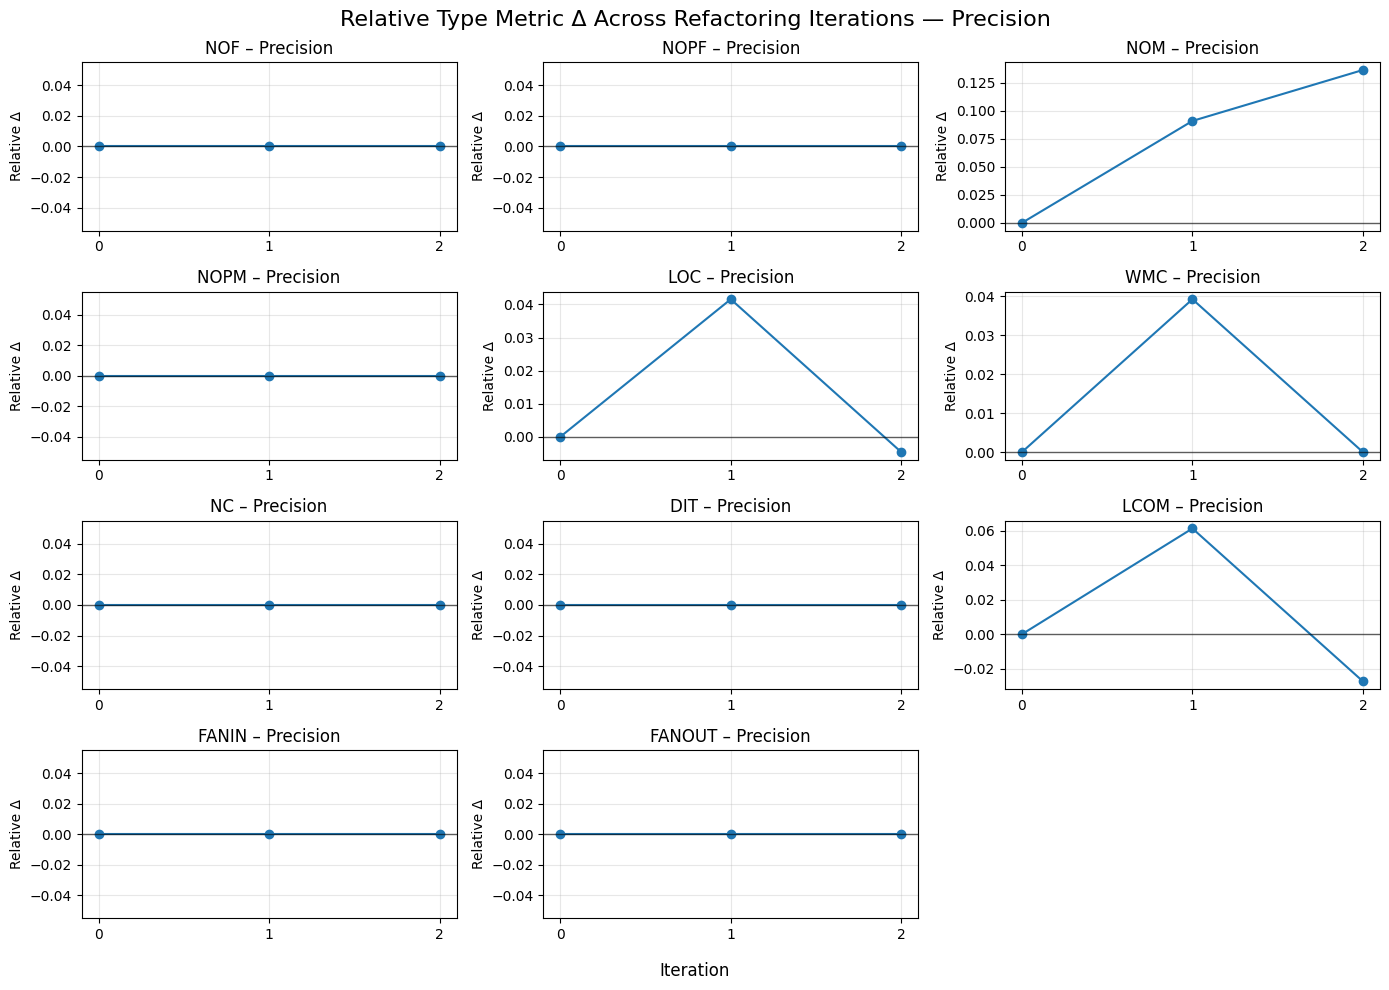

Plotting code smells for class: FastMath


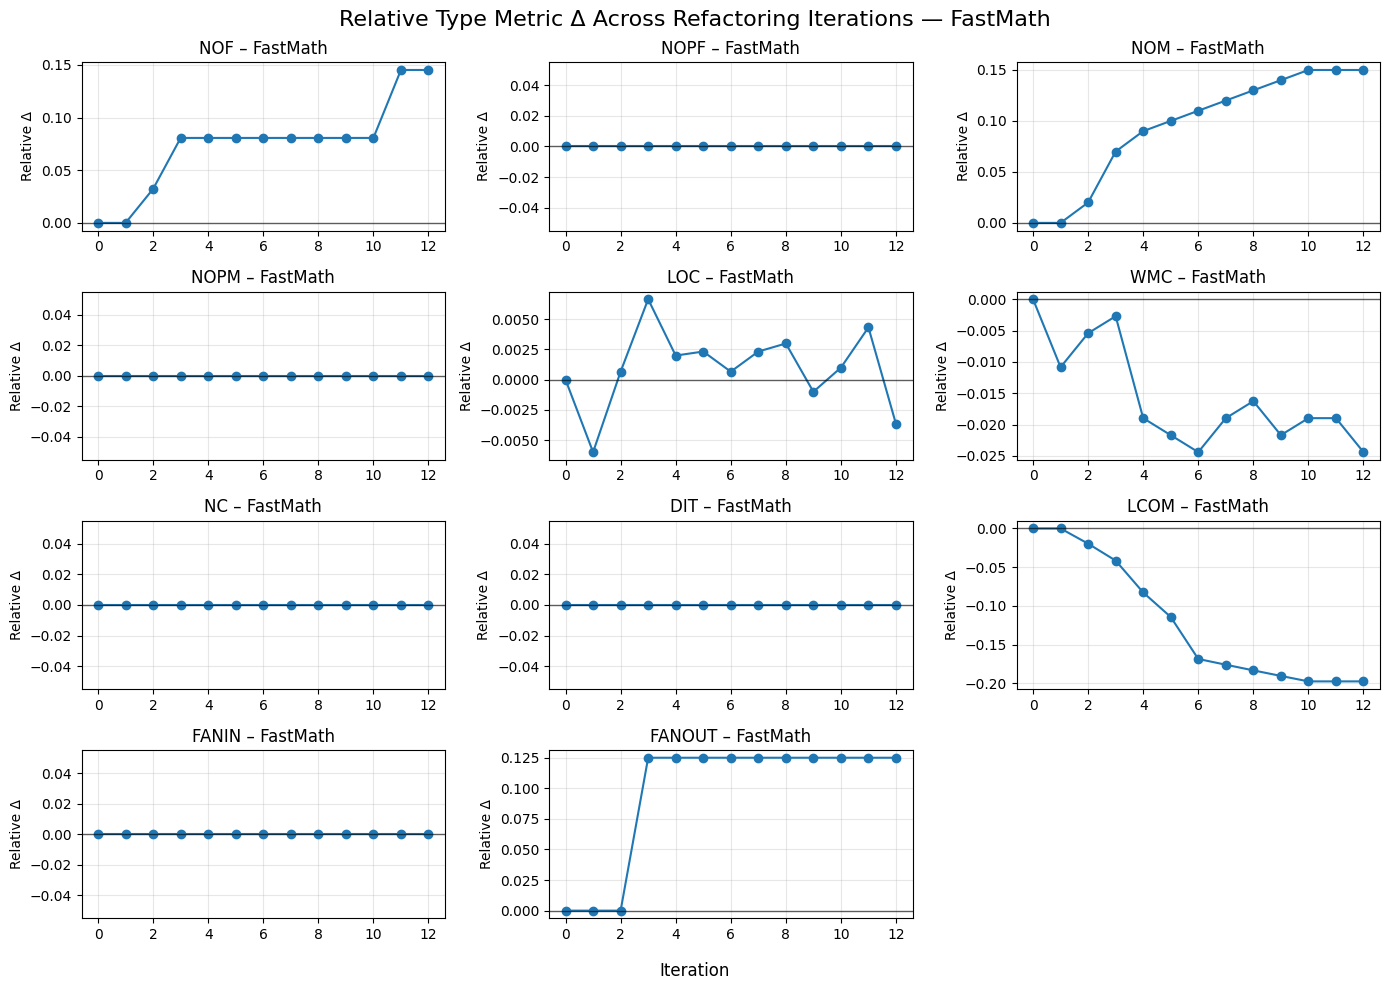

Plotting code smells for class: MathArrays


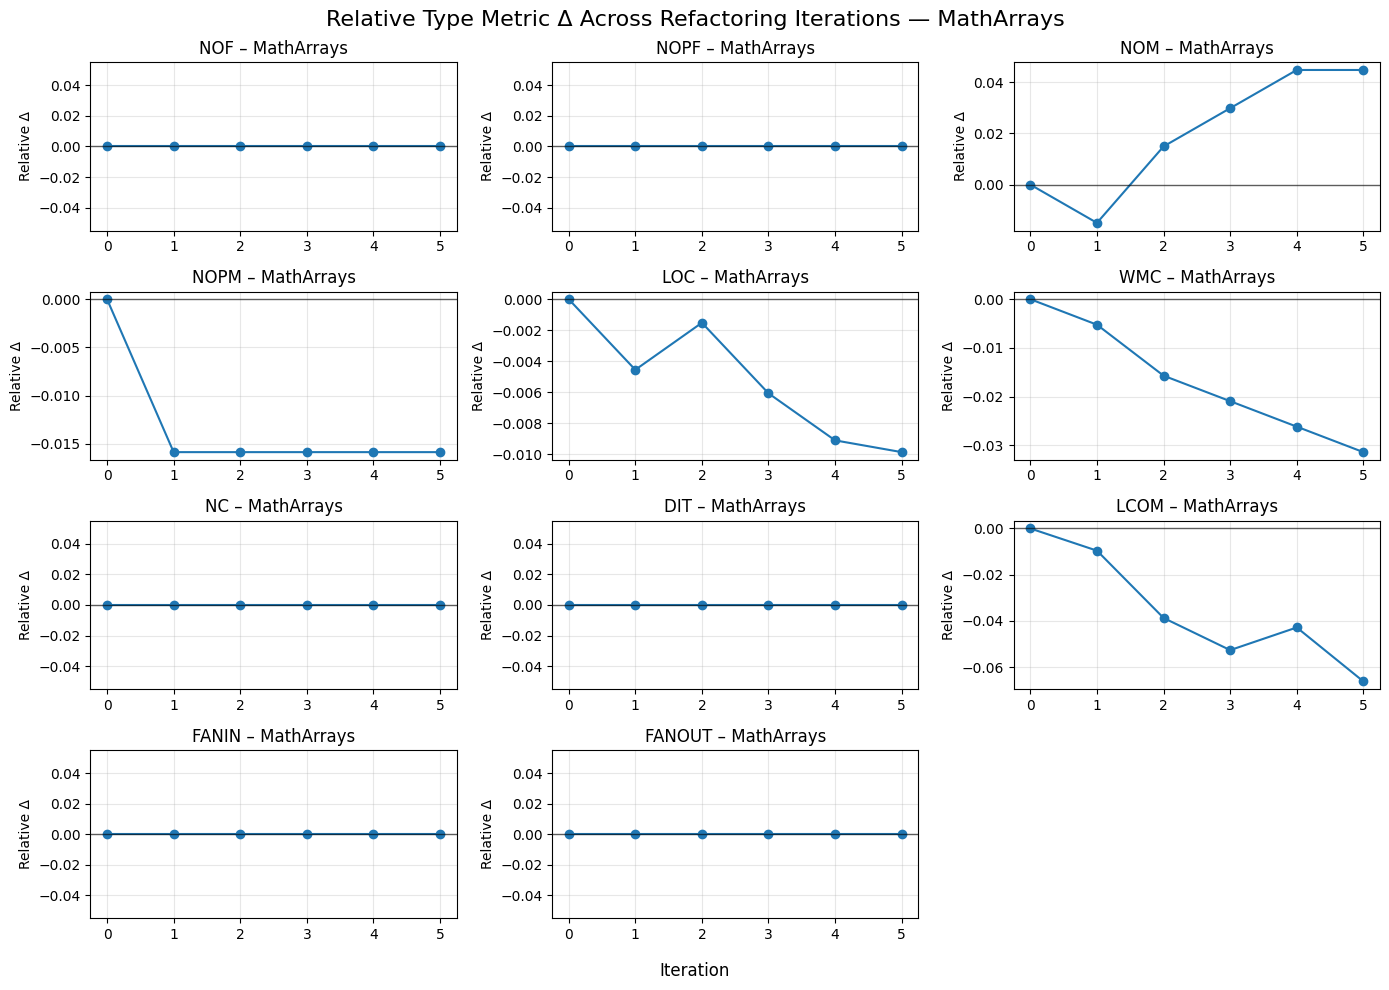

Plotting code smells for class: Array2DRowRealMatrix


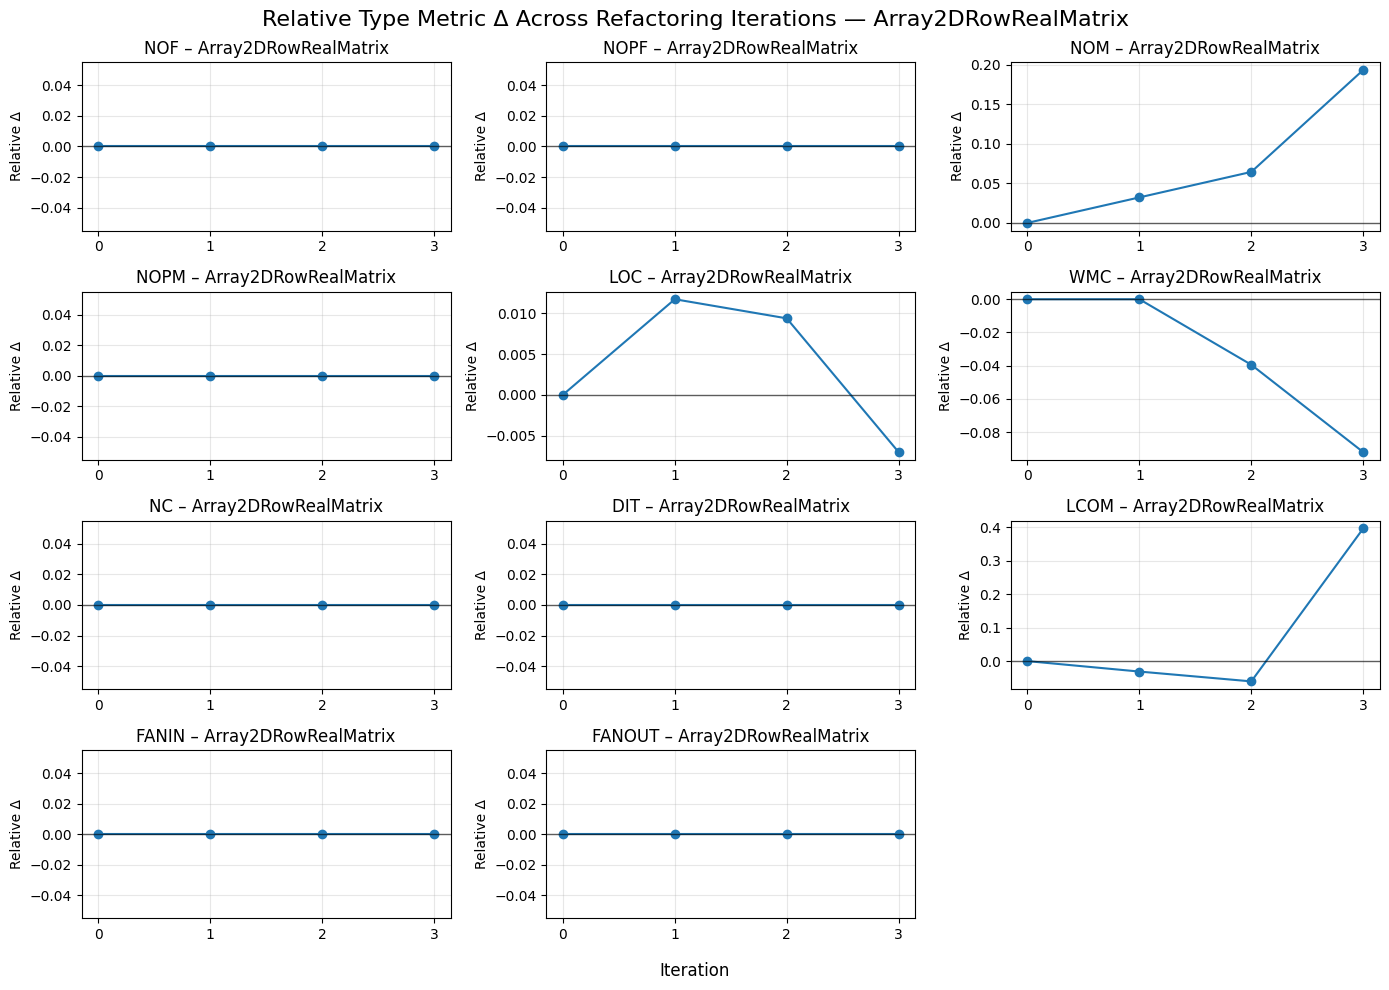

Plotting code smells for class: DescriptiveStatistics


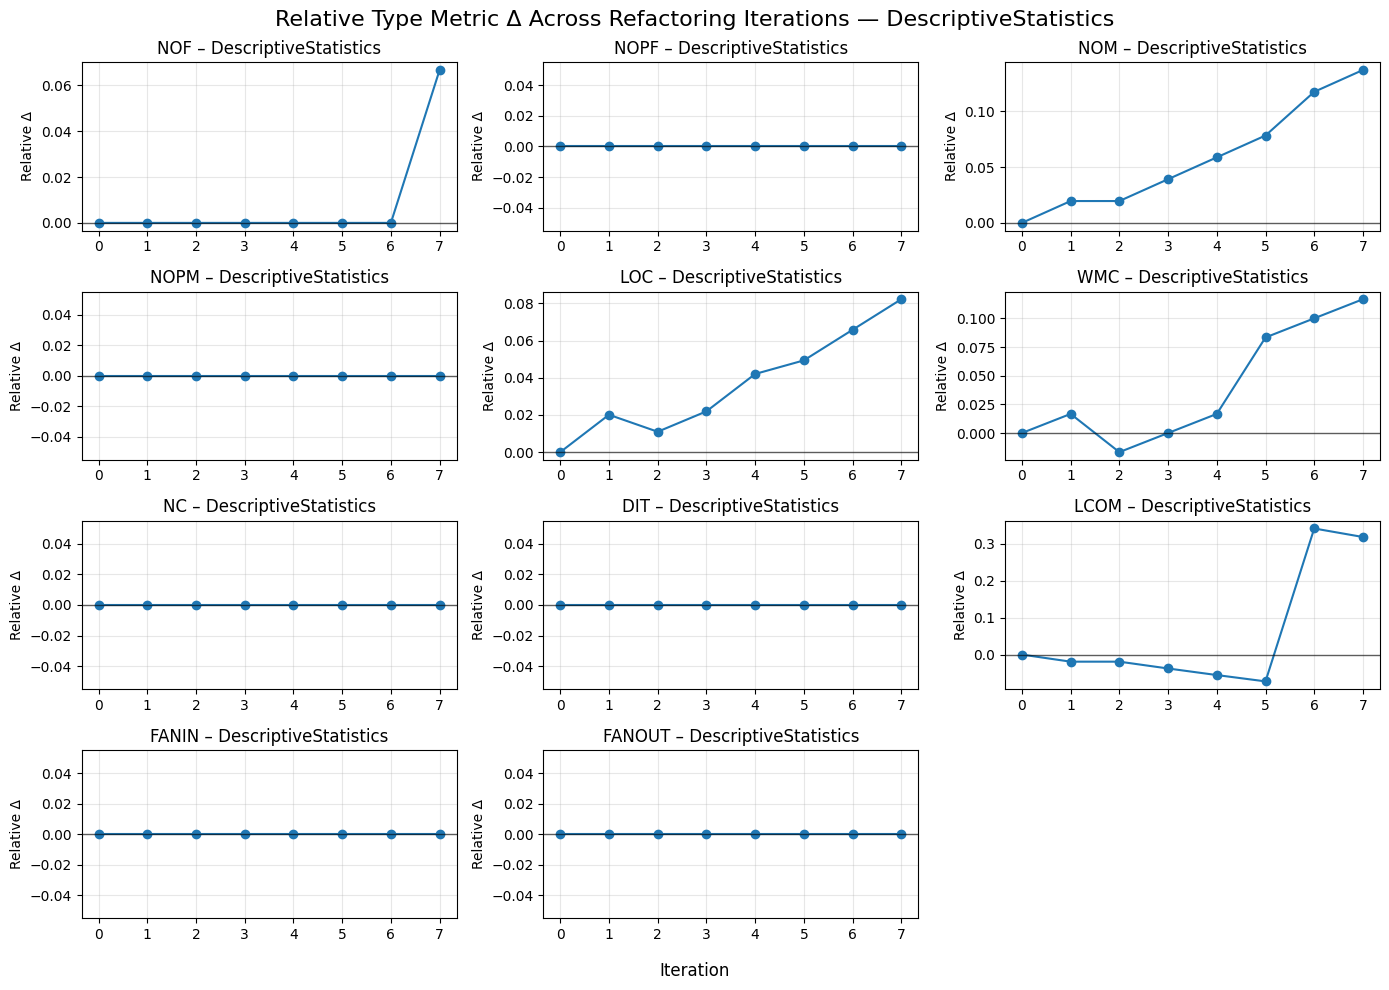

Plotting code smells for class: SimplexSolver


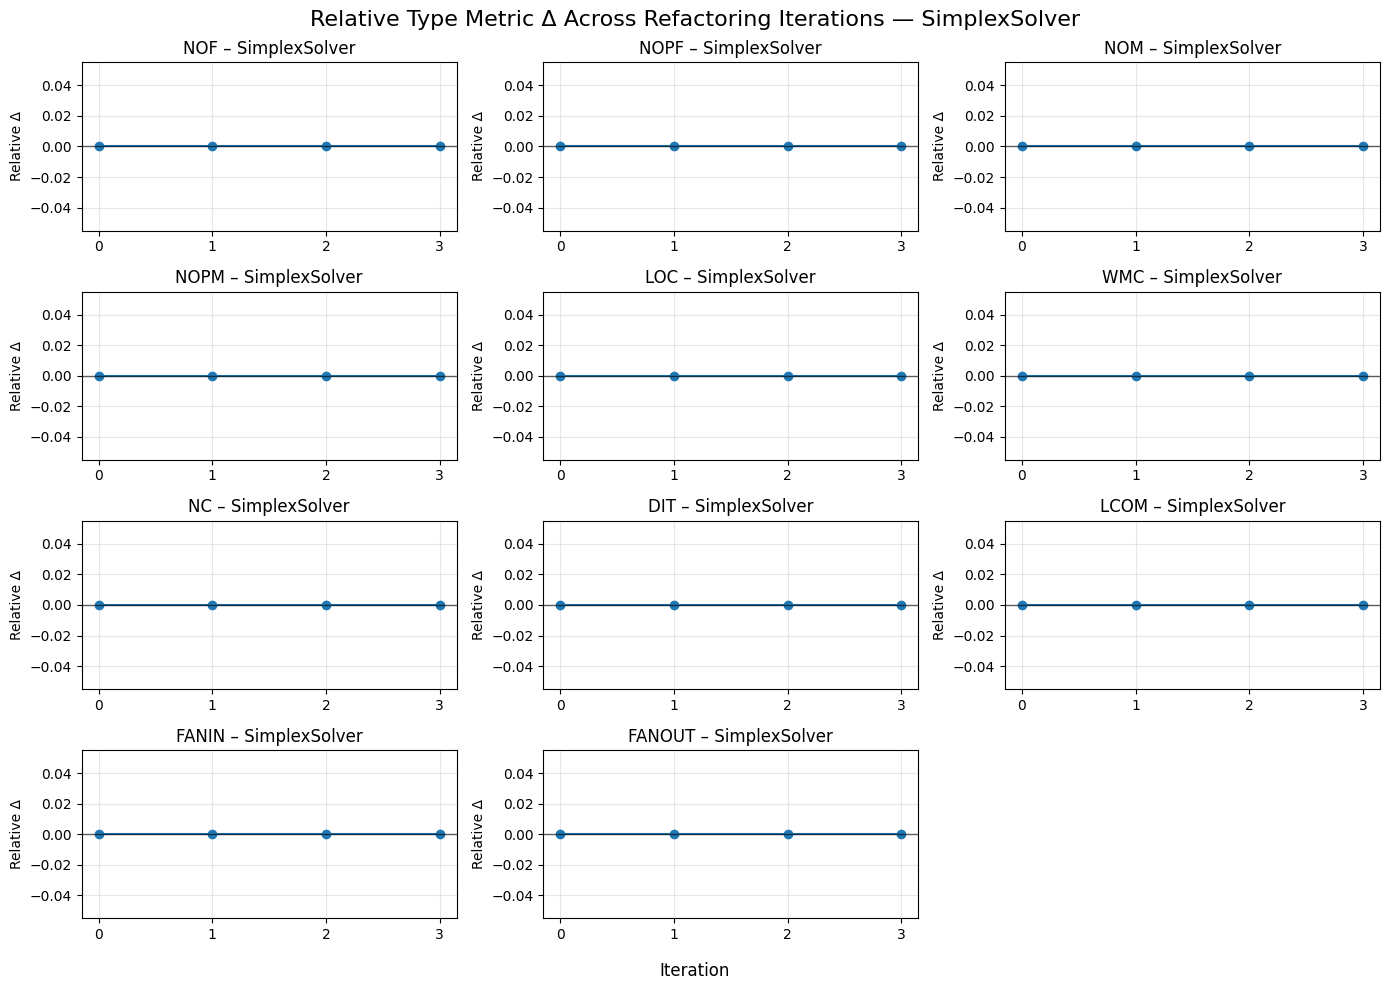

In [73]:
DESIGNITE_BASE_DIR = Path("designite")
for class_name in TARGET_CLASSES:
    csv_path = DESIGNITE_BASE_DIR / class_name / "designite_type_metrics.csv"

    if not csv_path.exists():
        print(f"[WARN] Missing file for {class_name}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df = df.drop(columns=['Project Name', 'Package Name', 'Type Name'])
    print(f"Plotting code smells for class: {class_name}")

    plot_relative_type_metrics_over_iterations(
        df,
        class_name=class_name,
        label_with_class = True
    )
